# KAP-BPCR Final Clean Structured Notebook

This notebook is organized as one clean project pipeline. It follows the final project requirements without repeated dataset loading, repeated target creation, or duplicated model evaluation blocks.

Pipeline:
1. Data loading and clinical framing
2. Advanced cleaning and missing data handling
3. Feature engineering
4. Feature selection
5. Modern machine learning models
6. Novel component
7. Robust evaluation
8. Explainability
9. Error analysis
10. Model comparison and efficiency
11. Final clinical conclusion

## Project Information

**Topic:** Knowledge, Attitudes & Practices on Birth Preparedness and Complication Readiness  
**Course:** Design and Analysis of Algorithms  
**Instructor:** Dr. Mekia Shigute GASO


## Stage 1 — Data Understanding, Clinical Framing & Advanced Preprocessing

### 1.0 Clinical Problem Definition

**Problem type:** Binary classification — *adequate vs. inadequate BPCR practice* (Birth Preparedness and Complication Readiness)

**Clinical relevance:** Ethiopia has one of the highest maternal mortality ratios globally (~401 per 100,000 live births, EDHS 2019). BPCR is a WHO-recommended strategy that significantly reduces delays in reaching emergency obstetric care. Women who identify a delivery place, save money, arrange transport, and identify a blood donor in advance are 3× more likely to receive timely care.

**Dataset structure (411 respondents, 73 raw variables):**
- **Section 1** — Demographics: age, marital status, occupation, education, income, family size
- **Section 2** — Knowledge: danger signs in pregnancy / delivery / postpartum + BPCR components
- **Section 3** — Attitudes: 5 Likert-scale items (ANC, SBA, transport, money, blood donor)
- **Section 4** — Practices (TARGET): 8 binary items — actual BPCR actions taken

**Bias considerations:**
- *Selection bias*: facility-based sample overrepresents ANC-attending women
- *Social desirability bias*: self-reported practices may be over-reported

**Missingness patterns:**
- `src_*` columns (59%): **MNAR** — missing only when `heard_bpcr = no`
- `kbc_*` columns (45%): **MAR** — conditional on `know_bpcr_components`
- `income` (2%): **MCAR** — random item non-response

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr, spearmanr, boxcox

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import (
    IsolationForest, RandomForestClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.base import clone
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.titlepad': 10, 'figure.facecolor': 'white'
})
PALETTE = ['#5B9BD5','#E07B54','#70AD47','#9B59B6','#F39C12','#1ABC9C','#E74C3C']
print('✓ Libraries loaded')

✓ Libraries loaded


### 1.1 Data Loading & Column Renaming

In [2]:
from pathlib import Path
DATA_CANDIDATES = [
    Path(r'D:\Downloads\KAP_BPCR_Data.xlsx'),
    Path(r'D:\Downloads\KAP_BPCR_Data(1).xlsx'),
    Path('KAP_BPCR_Data.xlsx'),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
assert DATA_PATH is not None, 'KAP_BPCR_Data.xlsx was not found'
print(f'Using dataset: {DATA_PATH}')
df_raw = pd.read_excel(DATA_PATH)

col_rename = {
    '@_1_1_Age': 'age', '@_1_2_Marital_status': 'marital',
    '@_1_3_Occupation_of_the_women': 'occ_women',
    '@_1_4_Educational_status_of_the_women': 'edu_women',
    '@_1_5_Occupation_of_the_husband': 'occ_husband',
    '@_1_6_Educational_status_of_the_Husband': 'edu_husband',
    '@_1_7_What_is_your_average_monthly_income': 'income',
    '@_1_8_Family_size': 'family_size',
    '@_2_1_Do_you_know_any_serious_h': 'know_preg_danger',
    '@_2_2_If_Yes_to_Q2_1_what_are_vaginal_bleeding': 'k_vaginal_bleeding',
    '@_2_2_If_Yes_to_Q2_1_what_are_body_swelling': 'k_body_swelling',
    '@_2_2_If_Yes_to_Q2_1_what_are_severe_headache': 'k_severe_headache',
    '@_2_2_If_Yes_to_Q2_1_what_are_severe_abdominal_pain': 'k_abdominal_pain',
    '@_2_2_If_Yes_to_Q2_1_what_are_blurring_of_vision': 'k_blurring_vision',
    '@_2_2_If_Yes_to_Q2_1_what_are_reduced_fetal_movement': 'k_fetal_movement',
    '@_2_3_Do_you_know_any_serious_h': 'know_deliv_danger',
    '@_2_4_If_Yes_to_Q2_3_what_are_severe_vaginal_bleeding': 'k_svb_deliv',
    '@_2_4_If_Yes_to_Q2_3_what_are_prolonged_delivery_of_placenta': 'k_placenta',
    '@_2_4_If_Yes_to_Q2_3_what_are_convulsion': 'k_convulsion',
    '@_2_4_If_Yes_to_Q2_3_what_are_prolonged_labour': 'k_prolonged_labour',
    '@_2_5_Do_you_know_the_serious_h': 'know_pp_danger',
    '@_2_6_If_Yes_to_Q2_5_what_are_severe_vaginal_bleeding': 'k_svb_pp',
    '@_2_6_If_Yes_to_Q2_5_what_are_malodorous_vaginal_bleeding': 'k_malodorous',
    '@_2_6_If_Yes_to_Q2_5_what_are_swelling_of_leg': 'k_leg_swelling',
    '@_2_6_If_Yes_to_Q2_5_what_are_high_grade_fever': 'k_fever',
    '@_2_6_If_Yes_to_Q2_5_what_are_severe_weakness': 'k_weakness',
    '@_2_7_Have_you_ever_heard_the_t': 'heard_bpcr',
    '@_2_8_If_Yes_to_Q2_7_from_whomhealth_professional': 'src_hp',
    '@_2_8_If_Yes_to_Q2_7_from_whomttba': 'src_ttba',
    '@_2_8_If_Yes_to_Q2_7_from_whomhew': 'src_hew',
    '@_2_8_If_Yes_to_Q2_7_from_whommass_media': 'src_media',
    '@_2_8_If_Yes_to_Q2_7_from_whommothers': 'src_mothers',
    '@_2_9_Do_you_know_the_things_th': 'know_bpcr_components',
    '@_2_10_If_Yes_to_Q2_9_what_areidentify_place_of_delivery': 'kbc_place',
    '@_2_10_If_Yes_to_Q2_9_what_areidentified_skilled_birth_attendant': 'kbc_sba',
    '@_2_10_If_Yes_to_Q2_9_what_aresave_money': 'kbc_money',
    '@_2_10_If_Yes_to_Q2_9_what_arebeing_aware_of_an_emergency_and_th': 'kbc_emergency',
    '@_2_10_If_Yes_to_Q2_9_what_areidentify_mode_of_transportation': 'kbc_transport',
    '@_2_10_If_Yes_to_Q2_9_what_arearrange_for_blood_donors': 'kbc_blood',
    '@_2_10_If_Yes_to_Q2_9_what_areidentify_the_nearest_institution_t': 'kbc_nearest',
    '@_3_1_Attend_ANC_foll_r_all_pregnant_women': 'att_anc',
    '@_3_2_Identify_a_skil_aternal_complication': 'att_sba',
    '@_3_3_Identify_mode_o_r_all_pregnant_women': 'att_transport',
    '@_3_4_Save_money_is_m_ary_during_pregnancy': 'att_money',
    '@_3_5_Identify_blood_egnancy_is_difficult': 'att_blood',
    '@_4_1_Do_you_identify_place_of_delivery': 'p_place',
    '@_4_2_Are_you_saving_money': 'p_money',
    '@_4_3_Have_you_identi_ied_skilled_provider': 'p_sba',
    '@_4_4_Can_you_detect_arly_signs_of_labour': 'p_signs',
    '@_4_5_Have_you_identi_de_of_transportation': 'p_transport',
    '@_4_6_Have_you_arranged_for_blood_donor': 'p_blood',
    '@_4_7_Have_you_arrang_or_a_birth_companion': 'p_companion',
    '@_4_8_Have_you_identi_oning_BEmONC_service': 'p_bemOnc',
}
df = df_raw.rename(columns=col_rename)
drop_cols = [c for c in df.columns if any(x in c for x in
             ['Other', '_what_are', '_from_whom', '@_index', 'Questionnaire', 'Maternal'])]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

print(f'Shape: {df.shape}')
df.head(3)

Using dataset: D:\Downloads\KAP_BPCR_Data.xlsx
Shape: (411, 53)


,age,marital,occ_women,edu_women,occ_husband,edu_husband,income,family_size,know_preg_danger,k_vaginal_bleeding,...,att_money,att_blood,p_place,p_money,p_sba,p_signs,p_transport,p_blood,p_companion,p_bemOnc
0,18.0,married,house_wife,primary_education,house_wife,primary_education,300.0,1.0,no,NaN,...,strongly_disagree,disagree,yes,yes,no,no,yes,yes,yes,yes
1,20.0,married,house_wife,primary_education,private_employee,primary_education,2000.0,1.0,no,NaN,...,strongly_disagree,disagree,yes,yes,no,no,yes,no,yes,yes
2,20.0,married,house_wife,primary_education,private_employee,primary_education,1200.0,2.0,no,NaN,...,strongly_disagree,disagree,yes,yes,yes,no,yes,no,yes,yes


### 1.2 Type Encoding & Target Construction

In [3]:
binary_cols = [c for c in ['know_preg_danger','know_deliv_danger','know_pp_danger',
    'heard_bpcr','know_bpcr_components','p_place','p_money','p_sba','p_signs',
    'p_transport','p_blood','p_companion','p_bemOnc'] if c in df.columns]
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

edu_order = {'unable_to_read_and_write': 0, 'able_to_read_and_write': 1,
             'primary_education': 2, 'secondary_education': 3, 'college_and_above': 4}
df['edu_women_ord']   = df['edu_women'].map(edu_order)
df['edu_husband_ord'] = df['edu_husband'].map(edu_order)

likert_map = {'strongly_disagree': 1, 'disagree': 2, 'neutral': 3, 'agree': 4, 'strongly_agree': 5}
for col in ['att_anc','att_sba','att_transport','att_money','att_blood']:
    if col in df.columns:
        df[col] = df[col].map(likert_map)

df['occ_women_enc']   = (df['occ_women'] == 'house_wife').astype(float)
df['occ_husband_enc'] = df['occ_husband'].isin(
    ['government_employee', 'private_employee']).astype(float)

practice_items = [c for c in ['p_place','p_money','p_sba','p_signs','p_transport',
                               'p_blood','p_companion','p_bemOnc'] if c in df.columns]
df['bpcr_score']    = df[practice_items].sum(axis=1)
df['bpcr_adequate'] = (df['bpcr_score'] >= 5).astype(int)
y_arr = df['bpcr_adequate'].values

know_sign_cols = [c for c in ['k_vaginal_bleeding','k_body_swelling','k_severe_headache',
    'k_abdominal_pain','k_blurring_vision','k_fetal_movement','k_svb_deliv','k_placenta',
    'k_convulsion','k_prolonged_labour','k_svb_pp','k_malodorous','k_leg_swelling',
    'k_fever','k_weakness'] if c in df.columns]
df['total_knowledge'] = df[know_sign_cols].sum(axis=1)

numeric_features = [c for c in ['age','income','family_size','edu_women_ord','edu_husband_ord',
    'occ_women_enc','occ_husband_enc','know_preg_danger','know_deliv_danger','know_pp_danger',
    'k_vaginal_bleeding','k_body_swelling','k_severe_headache','k_abdominal_pain',
    'k_blurring_vision','k_fetal_movement','k_svb_deliv','k_placenta','k_convulsion',
    'k_prolonged_labour','k_svb_pp','k_malodorous','k_leg_swelling','k_fever','k_weakness',
    'heard_bpcr','src_hp','src_ttba','src_hew','src_media','src_mothers',
    'know_bpcr_components','kbc_place','kbc_sba','kbc_money','kbc_emergency',
    'kbc_transport','kbc_blood','kbc_nearest',
    'att_anc','att_sba','att_transport','att_money','att_blood'] if c in df.columns]

X_df = df[numeric_features].copy()
print(f'Feature matrix: {X_df.shape}')
print(f'Target: {dict(pd.Series(y_arr).value_counts())}')
print(f'Total missing cells: {X_df.isnull().sum().sum()}')

Feature matrix: (411, 44)
Target: {1: np.int64(332), 0: np.int64(79)}
Total missing cells: 4218


### 1.3 Demographic & Target Visualizations

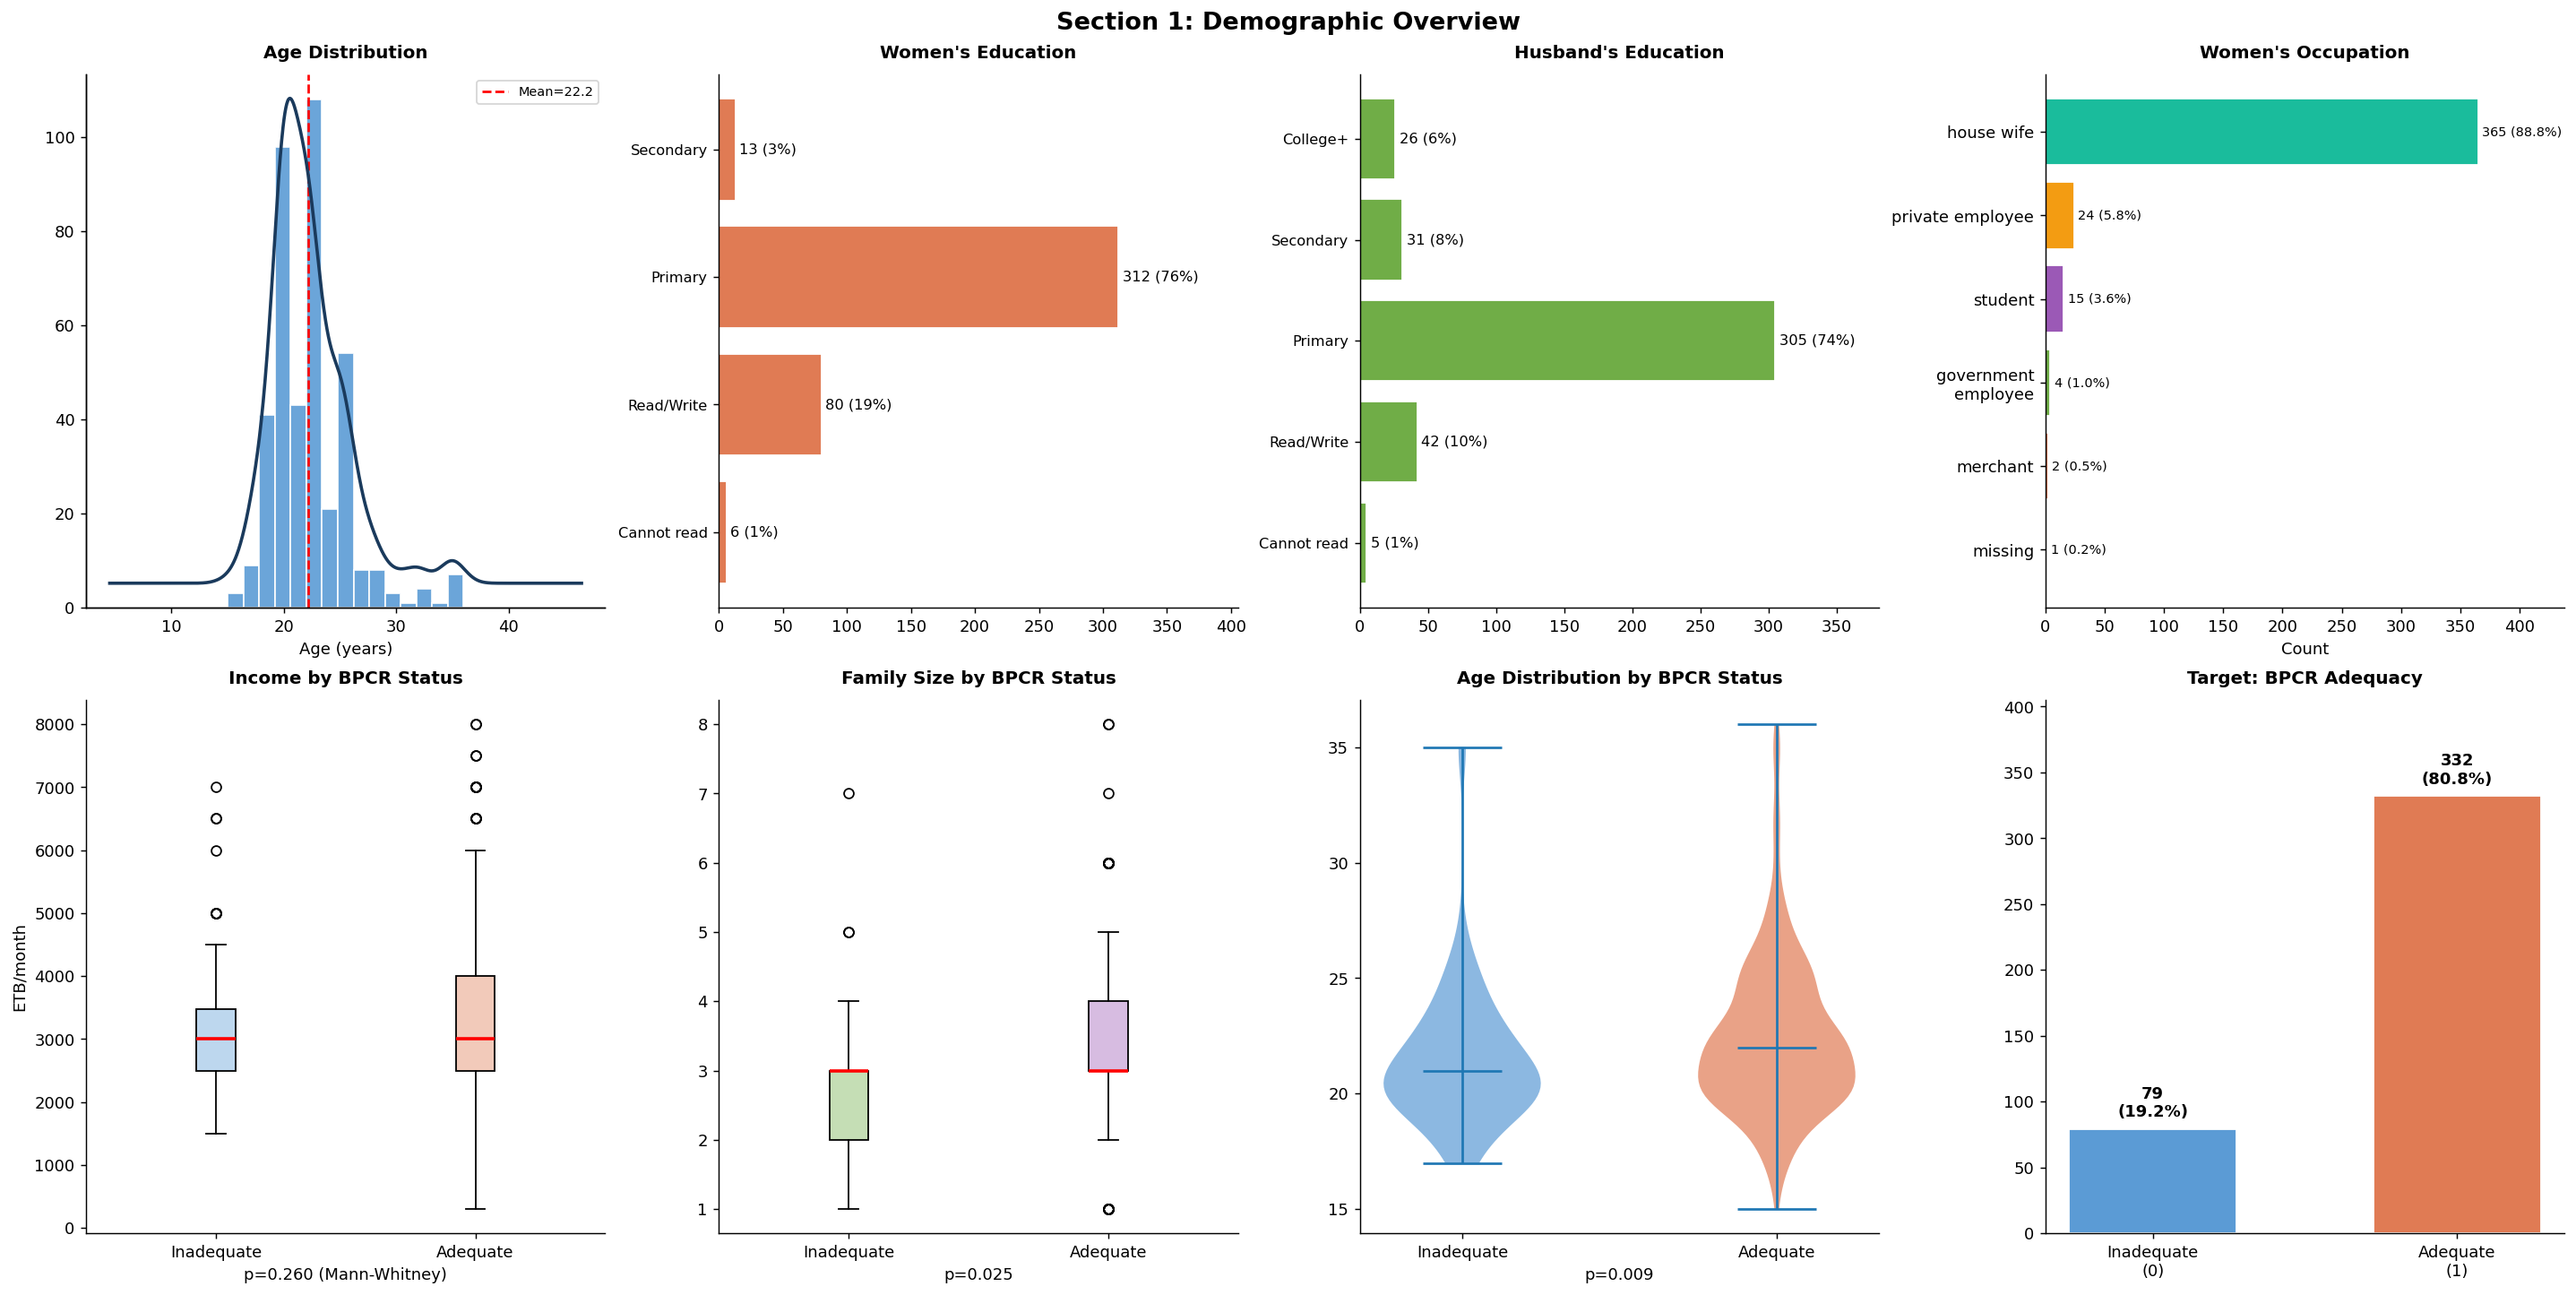

In [4]:
from textwrap import wrap

def wrap_label(label, width=16):
    """Wrap long matplotlib tick/legend labels into multiple short lines."""
    label = str(label).replace('_', ' ')
    return '\n'.join(wrap(label, width=width, break_long_words=False))

def wrap_axis_labels(ax, axis='x', width=14, rotation=None, fontsize=8):
    """Apply readable wrapped tick labels to one axis."""
    if axis == 'x':
        labels = [wrap_label(t.get_text(), width) for t in ax.get_xticklabels()]
        ax.set_xticklabels(labels, rotation=0 if rotation is None else rotation,
                           ha='center' if rotation in (None, 0) else 'right', fontsize=fontsize)
    else:
        labels = [wrap_label(t.get_text(), width) for t in ax.get_yticklabels()]
        ax.set_yticklabels(labels, fontsize=fontsize)

def clean_axes_grid(axes, x_width=12, y_width=20):
    """Light cleanup for subplot grids with dense category labels."""
    for ax in np.ravel(axes):
        if len(ax.get_xticklabels()) > 0:
            wrap_axis_labels(ax, 'x', width=x_width, fontsize=8)
        if len(ax.get_yticklabels()) > 0:
            wrap_axis_labels(ax, 'y', width=y_width, fontsize=8)
        ax.margins(x=0.04, y=0.06)

fig, axes = plt.subplots(2, 4, figsize=(22, 11), constrained_layout=True)
axes = axes.flatten()
PALETTE = ['#5B9BD5', '#E07B54', '#70AD47', '#9B59B6',
           '#F39C12', '#1ABC9C', '#E74C3C', '#7F8C8D']

axes[0].hist(df['age'].dropna(), bins=15, color=PALETTE[0], edgecolor='white', alpha=0.9)
ax2 = axes[0].twinx()
df['age'].dropna().plot.kde(ax=ax2, color='#1a3a5c', lw=2)
ax2.set_ylabel(''); ax2.set_yticks([])
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age (years)')
axes[0].axvline(df['age'].mean(), color='red', ls='--', lw=1.5,
                label=f'Mean={df["age"].mean():.1f}')
axes[0].legend(fontsize=8, loc='upper right')

edu_labels = {0:'Cannot read', 1:'Read/Write', 2:'Primary', 3:'Secondary', 4:'College+'}
edu_counts = df['edu_women_ord'].value_counts().sort_index()
edu_y = [edu_labels.get(i, str(i)) for i in edu_counts.index]
bars = axes[1].barh(edu_y, edu_counts.values, color=PALETTE[1], edgecolor='white')
for bar, val in zip(bars, edu_counts.values):
    axes[1].text(val + max(edu_counts.max()*0.01, 1), bar.get_y()+bar.get_height()/2,
                 f'{val} ({100*val/len(df):.0f}%)', va='center', fontsize=9)
axes[1].set_title("Women's Education")
axes[1].set_xlim(0, edu_counts.max()*1.30)
wrap_axis_labels(axes[1], 'y', width=14, fontsize=9)


edu_h_counts = df['edu_husband_ord'].value_counts().sort_index()
edu_h_y = [edu_labels.get(i, str(i)) for i in edu_h_counts.index]
bars_h = axes[2].barh(edu_h_y, edu_h_counts.values, color=PALETTE[2], edgecolor='white')
for bar, val in zip(bars_h, edu_h_counts.values):
    axes[2].text(val + max(edu_h_counts.max()*0.01, 1), bar.get_y()+bar.get_height()/2,
                 f'{val} ({100*val/len(df):.0f}%)', va='center', fontsize=9)
axes[2].set_title("Husband's Education")
axes[2].set_xlim(0, edu_h_counts.max()*1.25)
wrap_axis_labels(axes[2], 'y', width=14, fontsize=9)


occ_w = df['occ_women'].fillna('missing').value_counts()
occ_plot = occ_w.sort_values()
colors_occ = [PALETTE[i % len(PALETTE)] for i in range(len(occ_plot))]
bars_occ = axes[3].barh([wrap_label(x, 18) for x in occ_plot.index], occ_plot.values,
                         color=colors_occ, edgecolor='white')
for bar, val in zip(bars_occ, occ_plot.values):
    axes[3].text(val + max(occ_plot.max()*0.01, 0.5), bar.get_y()+bar.get_height()/2,
                 f'{val} ({100*val/len(df):.1f}%)', va='center', fontsize=8)
axes[3].set_title("Women's Occupation")
axes[3].set_xlabel('Count')
axes[3].set_xlim(0, occ_plot.max()*1.20)


inc_0 = df[df['bpcr_adequate']==0]['income'].dropna()
inc_1 = df[df['bpcr_adequate']==1]['income'].dropna()
bp = axes[4].boxplot([inc_0, inc_1], patch_artist=True,
                      labels=['Inadequate', 'Adequate'],
                      medianprops={'color':'red','lw':2})
bp['boxes'][0].set_facecolor(PALETTE[0]+'66')
bp['boxes'][1].set_facecolor(PALETTE[1]+'66')
axes[4].set_title('Income by BPCR Status')
axes[4].set_ylabel('ETB/month')
_, pval = stats.mannwhitneyu(inc_0, inc_1)
axes[4].set_xlabel(f'p={pval:.3f} (Mann-Whitney)')


fam_0 = df[df['bpcr_adequate']==0]['family_size'].dropna()
fam_1 = df[df['bpcr_adequate']==1]['family_size'].dropna()
bp2 = axes[5].boxplot([fam_0, fam_1], patch_artist=True,
                       labels=['Inadequate', 'Adequate'],
                       medianprops={'color':'red','lw':2})
bp2['boxes'][0].set_facecolor(PALETTE[2]+'66')
bp2['boxes'][1].set_facecolor(PALETTE[3]+'66')
axes[5].set_title('Family Size by BPCR Status')
_, pval_f = stats.mannwhitneyu(fam_0, fam_1)
axes[5].set_xlabel(f'p={pval_f:.3f}')


age_0 = df[df['bpcr_adequate']==0]['age'].dropna()
age_1 = df[df['bpcr_adequate']==1]['age'].dropna()
parts = axes[6].violinplot([age_0, age_1], positions=[1,2], showmedians=True, showmeans=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor([PALETTE[0], PALETTE[1]][i]); pc.set_alpha(0.7)
axes[6].set_xticks([1,2]); axes[6].set_xticklabels(['Inadequate', 'Adequate'])
axes[6].set_title('Age Distribution by BPCR Status')
_, pv_a = stats.mannwhitneyu(age_0, age_1)
axes[6].set_xlabel(f'p={pv_a:.3f}')


tc = df['bpcr_adequate'].value_counts().reindex([0, 1], fill_value=0)
bars_t = axes[7].bar(['Inadequate\n(0)', 'Adequate\n(1)'], tc.values,
                     color=[PALETTE[0], PALETTE[1]], edgecolor='white', width=0.55)
for bar, val in zip(bars_t, tc.values):
    axes[7].text(bar.get_x()+bar.get_width()/2, val + tc.max()*0.02,
                 f'{val}\n({100*val/len(df):.1f}%)', ha='center', va='bottom',
                 fontweight='bold', fontsize=10)
axes[7].set_title('Target: BPCR Adequacy')
axes[7].set_ylim(0, tc.max()*1.22)

fig.suptitle('Section 1: Demographic Overview', fontsize=15, fontweight='bold')
plt.savefig('fig_demographics.png', bbox_inches='tight', dpi=150)
plt.show()

### 1.4 Missingness Analysis

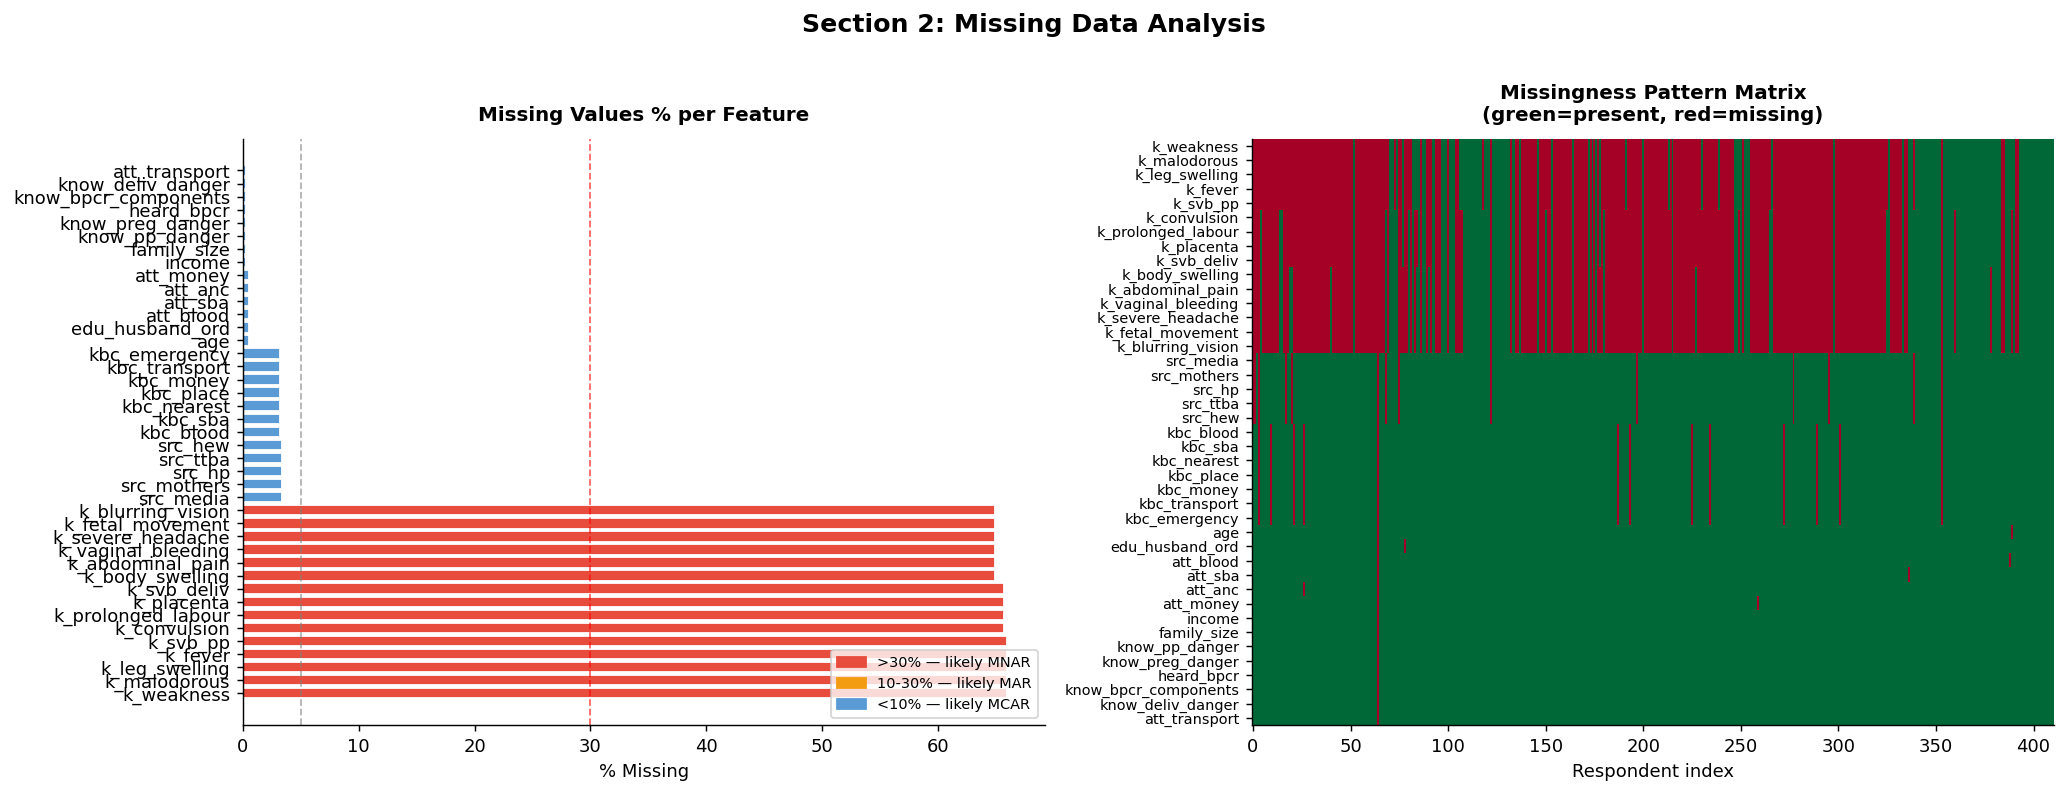

k_weakness              65.936740
k_malodorous            65.936740
k_leg_swelling          65.936740
k_fever                 65.936740
k_svb_pp                65.936740
k_convulsion            65.693431
k_prolonged_labour      65.693431
k_placenta              65.693431
k_svb_deliv             65.693431
k_body_swelling         64.963504
k_abdominal_pain        64.963504
k_vaginal_bleeding      64.963504
k_severe_headache       64.963504
k_fetal_movement        64.963504
k_blurring_vision       64.963504
src_media                3.406326
src_mothers              3.406326
src_hp                   3.406326
src_ttba                 3.406326
src_hew                  3.406326
kbc_blood                3.163017
kbc_sba                  3.163017
kbc_nearest              3.163017
kbc_place                3.163017
kbc_money                3.163017
kbc_transport            3.163017
kbc_emergency            3.163017
age                      0.486618
edu_husband_ord          0.486618
att_blood     

In [5]:
missing_pct = (X_df.isnull().sum() / len(X_df) * 100).sort_values(ascending=False)
missing_pct_nonzero = missing_pct[missing_pct > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_miss = ['#E74C3C' if v > 30 else ('#F39C12' if v > 10 else '#5B9BD5')
               for v in missing_pct_nonzero.values]
axes[0].barh(missing_pct_nonzero.index, missing_pct_nonzero.values,
             color=colors_miss, edgecolor='white')
axes[0].axvline(5,  color='gray', ls='--', lw=1, alpha=0.6)
axes[0].axvline(30, color='red',  ls='--', lw=1, alpha=0.6)
axes[0].set_title('Missing Values % per Feature')
axes[0].set_xlabel('% Missing')
legend_e = [mpatches.Patch(color='#E74C3C', label='>30% — likely MNAR'),
            mpatches.Patch(color='#F39C12', label='10-30% — likely MAR'),
            mpatches.Patch(color='#5B9BD5', label='<10% — likely MCAR')]
axes[0].legend(handles=legend_e, fontsize=8, loc='lower right')

miss_matrix = X_df[missing_pct_nonzero.index].isnull().astype(int)
axes[1].imshow(miss_matrix.T.values, aspect='auto', cmap='RdYlGn_r', interpolation='nearest')
axes[1].set_xlabel('Respondent index')
axes[1].set_yticks(range(len(missing_pct_nonzero)))
axes[1].set_yticklabels(missing_pct_nonzero.index, fontsize=8)
axes[1].set_title('Missingness Pattern Matrix\n(green=present, red=missing)')

plt.suptitle('Section 2: Missing Data Analysis', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

print(missing_pct_nonzero.to_string())

### 1.5 Imputation Method Comparison

=== Imputation Comparison (5 seeds × 5-fold CV) ===


  Mean                     : F1=0.8852±0.0161  AUC=0.7114±0.0620


  Median                   : F1=0.8872±0.0179  AUC=0.7118±0.0632


  Mode                     : F1=0.8875±0.0167  AUC=0.7122±0.0627


  KNN (k=5)                : F1=0.8889±0.0183  AUC=0.7051±0.0685


  KNN (k=10)               : F1=0.8934±0.0190  AUC=0.7120±0.0748


  Iterative (MICE)         : F1=0.8889±0.0146  AUC=0.7025±0.0433


  Iterative (RF-based)     : F1=0.8937±0.0152  AUC=0.7354±0.0687


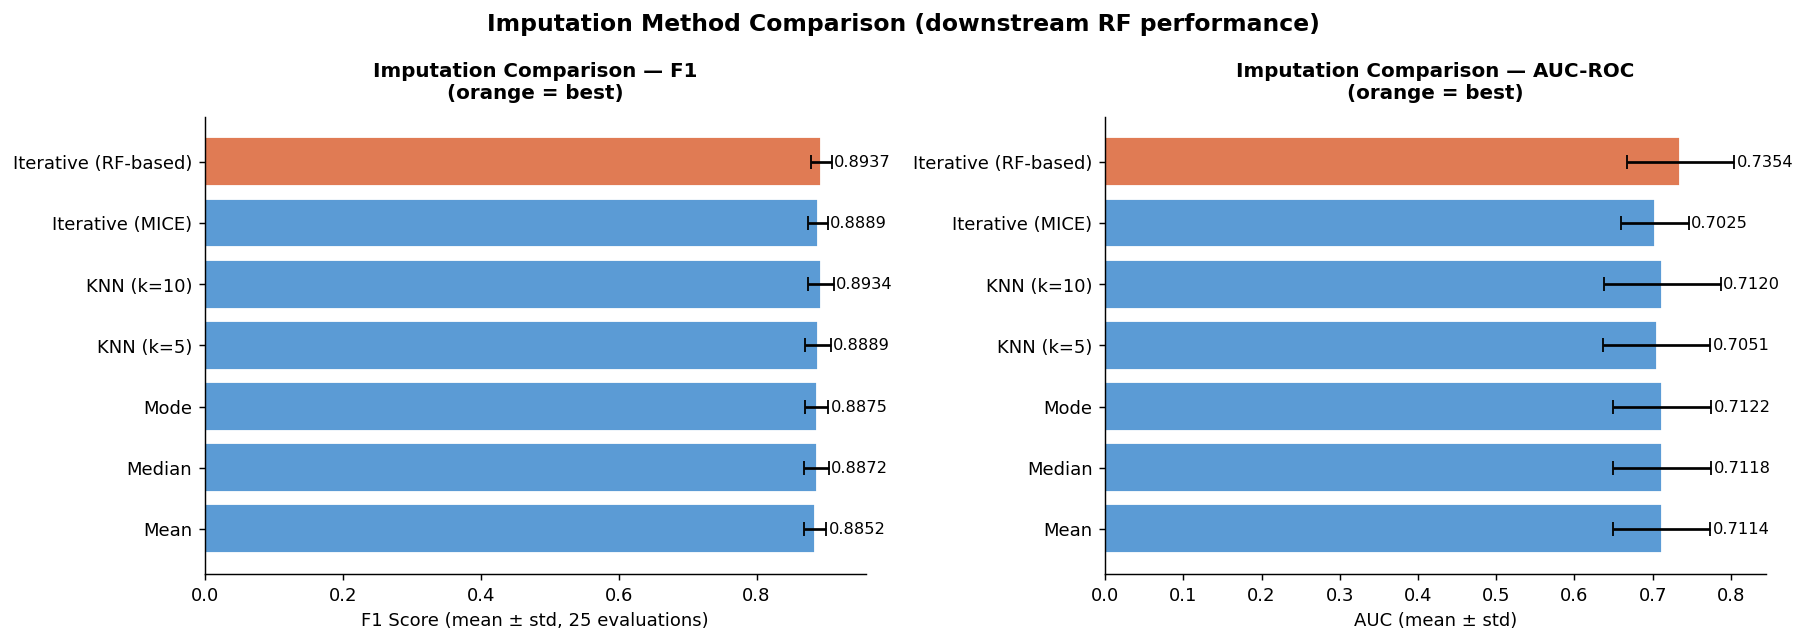


→ Best: Iterative (RF-based)  AUC=0.7354
→ X_imputed shape: (411, 44), missing: 0


In [6]:
X_raw = X_df.values.astype(float)

def eval_imputer(imputer, X, y, name, n_seeds=5):
    X_imp = imputer.fit_transform(X)
    all_f1, all_auc = [], []
    for seed in range(n_seeds):
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        clf = RandomForestClassifier(n_estimators=50, random_state=42)
        all_f1.extend(cross_val_score(clf, X_imp, y, cv=skf, scoring='f1'))
        all_auc.extend(cross_val_score(clf, X_imp, y, cv=skf, scoring='roc_auc'))
    print(f'  {name:25s}: F1={np.mean(all_f1):.4f}±{np.std(all_f1):.4f}  AUC={np.mean(all_auc):.4f}±{np.std(all_auc):.4f}')
    return {'name': name, 'X_imp': X_imp,
            'f1_mean': np.mean(all_f1), 'f1_std': np.std(all_f1),
            'auc_mean': np.mean(all_auc), 'auc_std': np.std(all_auc)}

print('=== Imputation Comparison (5 seeds × 5-fold CV) ===')
imp_results = []
imp_results.append(eval_imputer(SimpleImputer(strategy='mean'),        X_raw, y_arr, 'Mean'))
imp_results.append(eval_imputer(SimpleImputer(strategy='median'),      X_raw, y_arr, 'Median'))
imp_results.append(eval_imputer(SimpleImputer(strategy='most_frequent'), X_raw, y_arr, 'Mode'))
imp_results.append(eval_imputer(KNNImputer(n_neighbors=5),             X_raw, y_arr, 'KNN (k=5)'))
imp_results.append(eval_imputer(KNNImputer(n_neighbors=10),            X_raw, y_arr, 'KNN (k=10)'))
imp_results.append(eval_imputer(IterativeImputer(max_iter=10, random_state=42),
                                X_raw, y_arr, 'Iterative (MICE)'))
imp_results.append(eval_imputer(
    IterativeImputer(estimator=RandomForestClassifier(n_estimators=10, random_state=42),
                     max_iter=5, random_state=42),
    X_raw, y_arr, 'Iterative (RF-based)'))

best_idx    = np.argmax([r['auc_mean'] for r in imp_results])
best_method = imp_results[best_idx]
X_imputed   = best_method['X_imp']

names = [r['name'] for r in imp_results]
aucm  = [r['auc_mean'] for r in imp_results]
aucs  = [r['auc_std']  for r in imp_results]
f1m   = [r['f1_mean']  for r in imp_results]
f1s   = [r['f1_std']   for r in imp_results]
c_bars = [PALETTE[1] if i == best_idx else PALETTE[0] for i in range(len(names))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(names, f1m, xerr=f1s, color=c_bars, edgecolor='white', capsize=4)
for i, (m, s) in enumerate(zip(f1m, f1s)):
    axes[0].text(m+s+0.003, i, f'{m:.4f}', va='center', fontsize=9)
axes[0].set_title('Imputation Comparison — F1\n(orange = best)')
axes[0].set_xlabel('F1 Score (mean ± std, 25 evaluations)')

axes[1].barh(names, aucm, xerr=aucs, color=c_bars, edgecolor='white', capsize=4)
for i, (m, s) in enumerate(zip(aucm, aucs)):
    axes[1].text(m+s+0.003, i, f'{m:.4f}', va='center', fontsize=9)
axes[1].set_title('Imputation Comparison — AUC-ROC\n(orange = best)')
axes[1].set_xlabel('AUC (mean ± std)')

plt.suptitle('Imputation Method Comparison (downstream RF performance)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n→ Best: {best_method['name']}  AUC={best_method['auc_mean']:.4f}")
print(f'→ X_imputed shape: {X_imputed.shape}, missing: {np.isnan(X_imputed).sum()}')

### 1.6 Outlier Detection — Isolation Forest + Robust Z-score

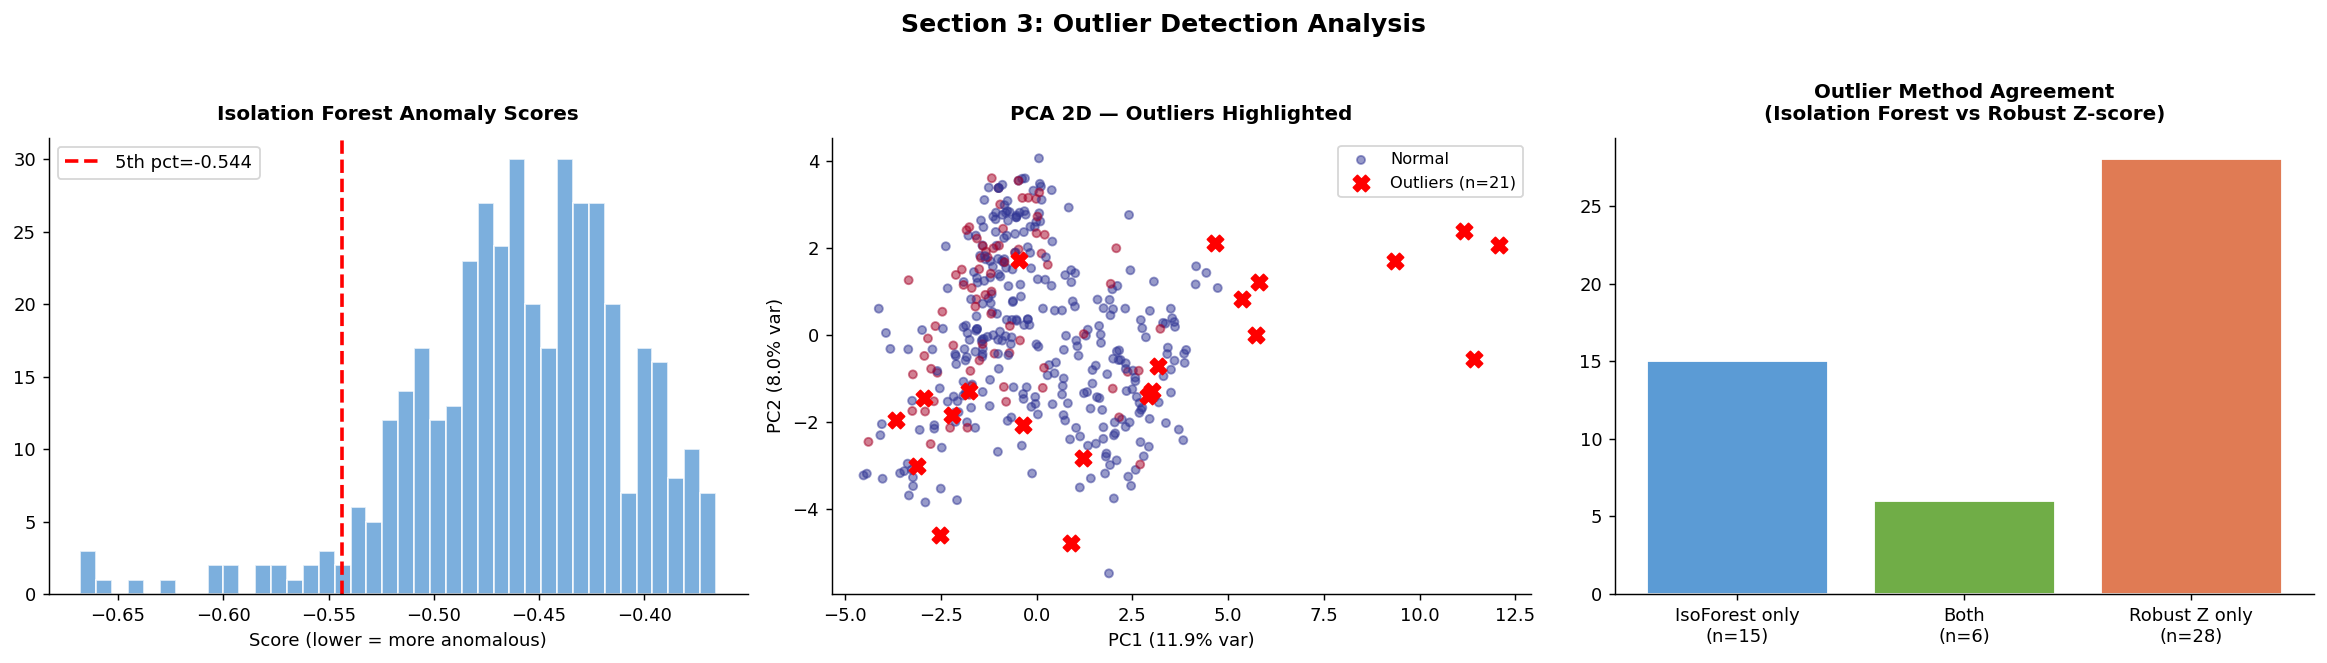


→ Outliers flagged (not removed): 21 (5.1%)
→ Final clean matrix: (411, 45)


In [7]:
from scipy.stats import median_abs_deviation

iso = IsolationForest(contamination=0.05, n_estimators=200, random_state=42)
outlier_labels = iso.fit_predict(X_imputed)
outlier_scores = iso.score_samples(X_imputed)
is_outlier     = (outlier_labels == -1)

continuous_idx = [i for i, c in enumerate(numeric_features)
                  if c in ['age', 'income', 'family_size']]
robust_outliers = np.zeros(len(X_imputed), dtype=bool)
for idx in continuous_idx:
    col_vals = X_imputed[:, idx]
    med = np.median(col_vals)
    mad = median_abs_deviation(col_vals)
    robust_outliers |= (np.abs(0.6745 * (col_vals - med) / (mad + 1e-8)) > 3.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(outlier_scores, bins=40, color=PALETTE[0], edgecolor='white', alpha=0.8)
thresh = np.percentile(outlier_scores, 5)
axes[0].axvline(thresh, color='red', ls='--', lw=2, label=f'5th pct={thresh:.3f}')
axes[0].set_title('Isolation Forest Anomaly Scores')
axes[0].set_xlabel('Score (lower = more anomalous)')
axes[0].legend()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X_imputed))
axes[1].scatter(X_pca[~is_outlier,0], X_pca[~is_outlier,1],
                c=y_arr[~is_outlier], cmap='RdYlBu', alpha=0.5, s=20, label='Normal')
axes[1].scatter(X_pca[is_outlier,0], X_pca[is_outlier,1],
                c='red', s=80, marker='X', zorder=5, label=f'Outliers (n={is_outlier.sum()})')
axes[1].set_title('PCA 2D — Outliers Highlighted')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[1].legend(fontsize=9)

iso_set = set(np.where(is_outlier)[0])
rob_set = set(np.where(robust_outliers)[0])
both    = iso_set & rob_set
venn_data   = [len(iso_set-both), len(both), len(rob_set-both)]
venn_labels = [f'IsoForest only\n(n={len(iso_set-both)})',
               f'Both\n(n={len(both)})',
               f'Robust Z only\n(n={len(rob_set-both)})']
axes[2].bar(venn_labels, venn_data, color=[PALETTE[0], PALETTE[2], PALETTE[1]], edgecolor='white')
axes[2].set_title('Outlier Method Agreement\n(Isolation Forest vs Robust Z-score)')

plt.suptitle('Section 3: Outlier Detection Analysis', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

outlier_flag = is_outlier.astype(int)
X_clean = np.column_stack([X_imputed, outlier_flag])
feature_names = numeric_features + ['is_outlier']
print(f'\n→ Outliers flagged (not removed): {is_outlier.sum()} ({100*is_outlier.mean():.1f}%)')
print(f'→ Final clean matrix: {X_clean.shape}')

### 1.7 Correlation Analysis

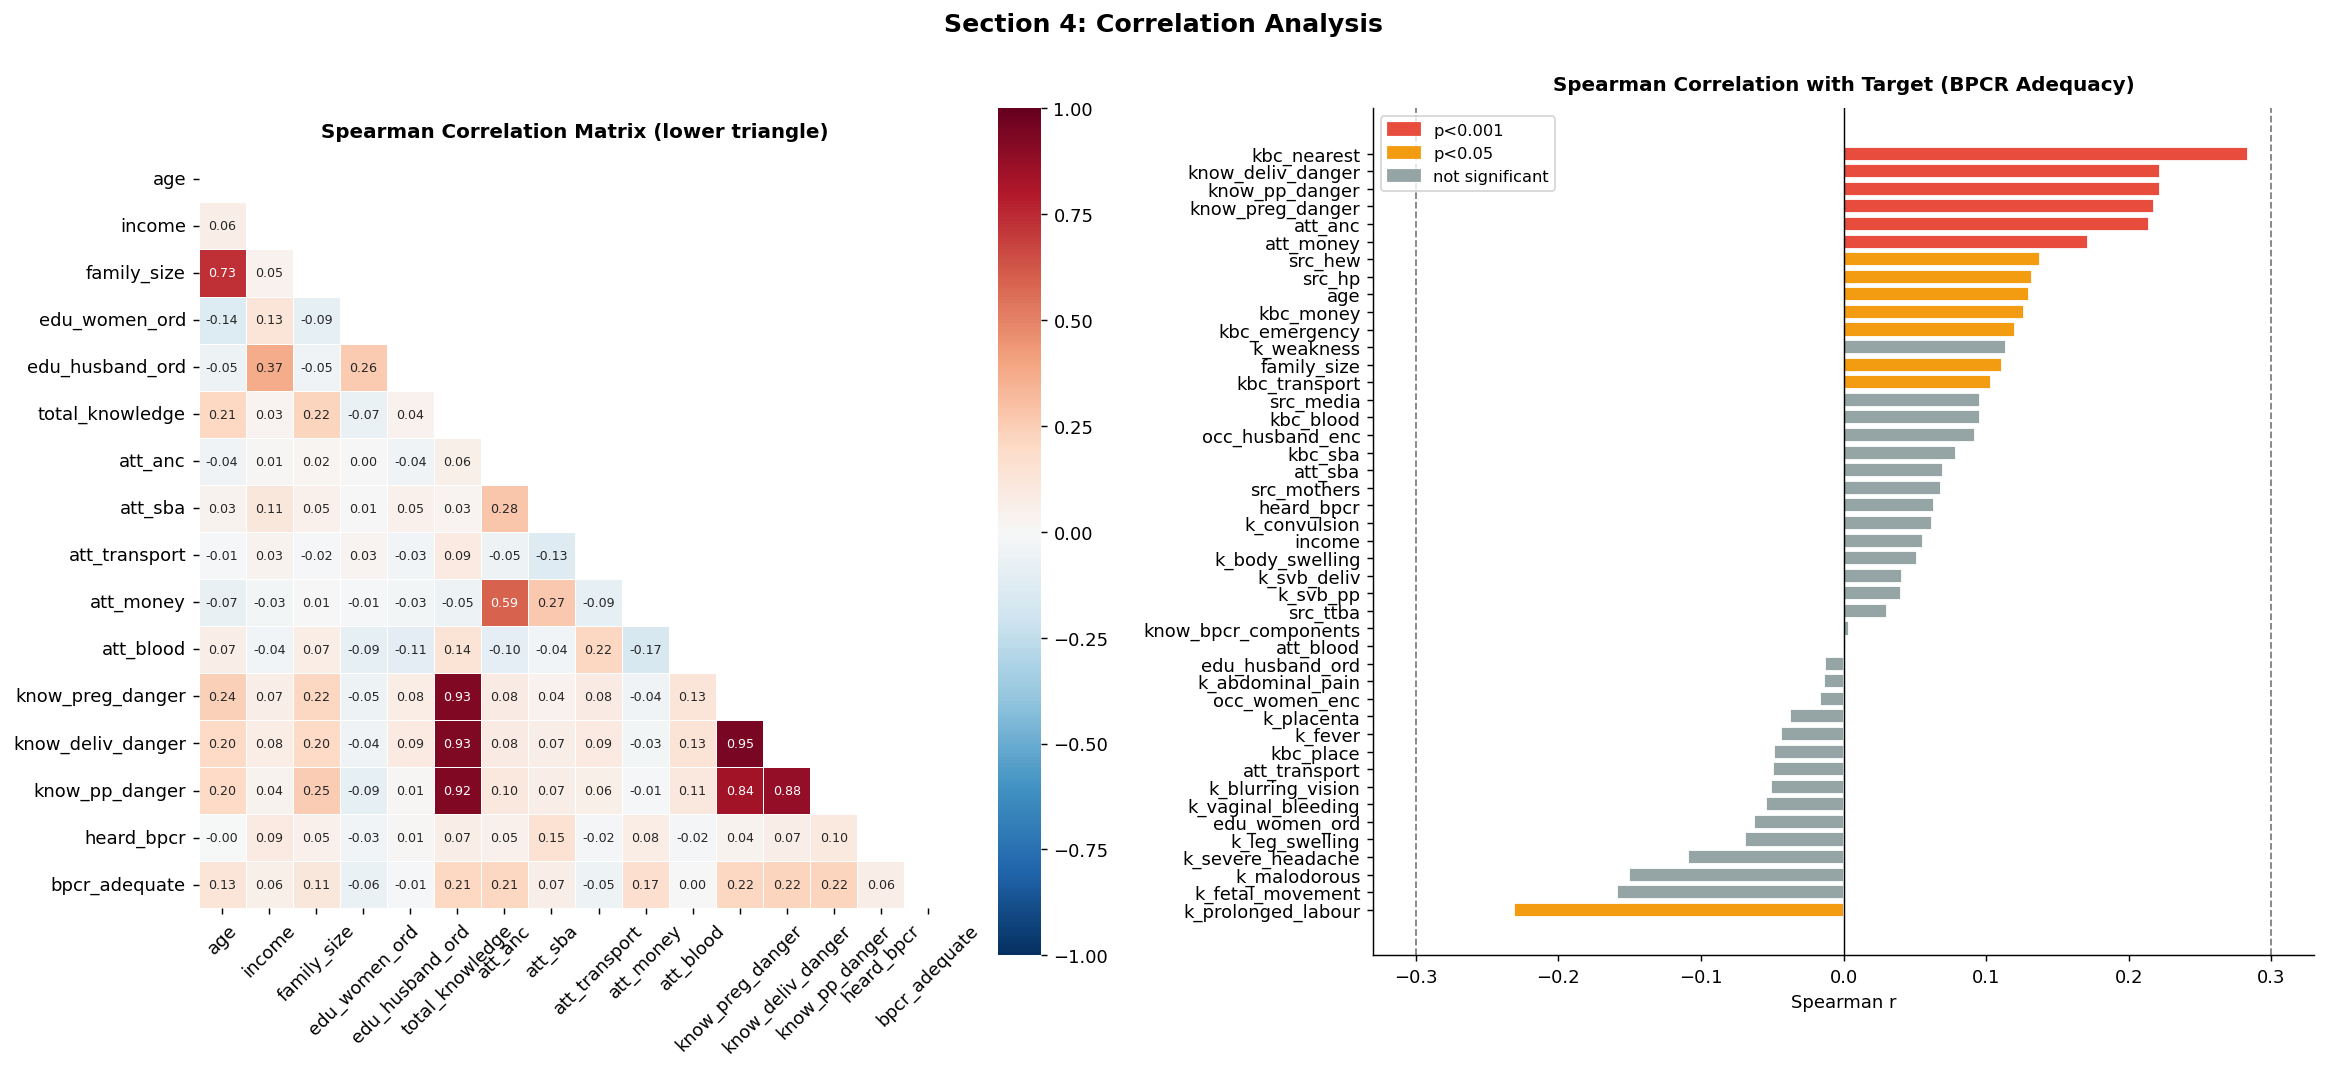

In [8]:
corr_subset = ['age','income','family_size','edu_women_ord','edu_husband_ord',
               'total_knowledge','att_anc','att_sba','att_transport','att_money','att_blood',
               'know_preg_danger','know_deliv_danger','know_pp_danger','heard_bpcr','bpcr_adequate']
corr_subset = [c for c in corr_subset if c in df.columns]

target_corr = {}
for col in numeric_features:
    if col in df.columns:
        valid = df[[col, 'bpcr_adequate']].dropna()
        if len(valid) > 20:
            r, p = spearmanr(valid[col], valid['bpcr_adequate'])
            target_corr[col] = {'r': r, 'p': p}
tc_df = pd.DataFrame(target_corr).T.sort_values('r')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

corr_matrix = df[corr_subset].corr(method='spearman')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=axes[0], annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 7}, square=True)
axes[0].set_title('Spearman Correlation Matrix (lower triangle)')
axes[0].tick_params(axis='x', rotation=45)

colors_tc = ['#E74C3C' if row['p'] < 0.001 else ('#F39C12' if row['p'] < 0.05 else '#95A5A6')
             for _, row in tc_df.iterrows()]
axes[1].barh(tc_df.index, tc_df['r'], color=colors_tc, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].axvline(0.3, color='gray', ls='--', lw=1)
axes[1].axvline(-0.3, color='gray', ls='--', lw=1)
axes[1].set_title('Spearman Correlation with Target (BPCR Adequacy)')
axes[1].set_xlabel('Spearman r')
legend_corr = [mpatches.Patch(color='#E74C3C', label='p<0.001'),
               mpatches.Patch(color='#F39C12', label='p<0.05'),
               mpatches.Patch(color='#95A5A6', label='not significant')]
axes[1].legend(handles=legend_corr, fontsize=9)

plt.suptitle('Section 4: Correlation Analysis', fontsize=14, y=1.0, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Stage 2 — Novel Feature Engineering (5 Methods)

Five engineering methods are applied:
1. **Domain-Inspired** — clinically motivated composite indices
2. **Interaction Features** — non-linear cross-products
3. **Statistical Transformations** — Box-Cox, quantile-normal, log1p
4. **Aggregation Features** — grouped danger-sign counts by period
5. **Autoencoder Extraction** — MLPRegressor bottleneck (43 → 8 latent dims)

In [9]:
X_fe = pd.DataFrame(X_imputed, columns=numeric_features)
X_fe['total_knowledge'] = df['total_knowledge'].values
X_fe['bpcr_score']      = df['bpcr_score'].values

X_fe['health_literacy_idx'] = (
    (X_fe['edu_women_ord'] / 4.0) * 0.40 +
    (X_fe['total_knowledge'] / 15.0) * 0.40 +
    X_fe['heard_bpcr'] * 0.20
)
X_fe['empowerment_score'] = (
    X_fe['edu_women_ord'] / 4.0 * 0.35 +
    (1 - X_fe['occ_women_enc']) * 0.30 +
    X_fe['occ_husband_enc'] * 0.20 +
    (X_fe['edu_husband_ord'] / 4.0) * 0.15
)
X_fe['knowledge_action_gap'] = (
    X_fe['know_bpcr_components'] - X_fe['heard_bpcr']
).clip(-1, 1)
X_fe['know_all_3periods'] = (
    (X_fe['know_preg_danger'] == 1) &
    (X_fe['know_deliv_danger'] == 1) &
    (X_fe['know_pp_danger'] == 1)
).astype(int)
src_cols = [c for c in ['src_hp','src_ttba','src_hew','src_media','src_mothers'] if c in X_fe.columns]
X_fe['info_diversity'] = X_fe[src_cols].sum(axis=1)
kbc_cols = [c for c in ['kbc_place','kbc_sba','kbc_money','kbc_emergency',
                        'kbc_transport','kbc_blood','kbc_nearest'] if c in X_fe.columns]
X_fe['kbc_count']       = X_fe[kbc_cols].sum(axis=1)
X_fe['kbc_completeness']= X_fe['kbc_count'] / len(kbc_cols)

att_cols_fe = [c for c in ['att_anc','att_sba','att_transport','att_money','att_blood'] if c in X_fe.columns]
X_fe['att_total']    = X_fe[att_cols_fe].mean(axis=1)
X_fe['att_positive'] = (X_fe[att_cols_fe] >= 4).sum(axis=1)
X_fe['att_variance'] = X_fe[att_cols_fe].std(axis=1)

X_fe['edu_x_know']      = X_fe['edu_women_ord'] * X_fe['total_knowledge']
X_fe['att_x_know']      = X_fe['att_total']     * X_fe['total_knowledge']
X_fe['edu_x_att']       = X_fe['edu_women_ord'] * X_fe['att_total']
X_fe['info_x_know']     = X_fe['info_diversity']* X_fe['total_knowledge']
X_fe['kbc_x_att']       = X_fe['kbc_count']     * X_fe['att_positive']
X_fe['family_x_income'] = X_fe['family_size']   / (X_fe['income'] + 1)

for col in ['income', 'family_size', 'age']:
    X_fe[f'log_{col}'] = np.log1p(X_fe[col])

qt = QuantileTransformer(n_quantiles=100, output_distribution='normal', random_state=42)
cont_cols = ['income','age','family_size','total_knowledge','att_total']
cont_cols = [c for c in cont_cols if c in X_fe.columns]
X_qt = qt.fit_transform(X_fe[cont_cols])
for i, col in enumerate(cont_cols):
    X_fe[f'qt_{col}'] = X_qt[:, i]

income_bc, lam = boxcox(X_fe['income'].values + 1)
X_fe['bc_income'] = income_bc
print(f'  Box-Cox λ for income: {lam:.4f}')

X_fe['age_teen']     = (X_fe['age'] < 20).astype(int)
X_fe['age_young']    = ((X_fe['age'] >= 20) & (X_fe['age'] < 25)).astype(int)
X_fe['age_prime']    = ((X_fe['age'] >= 25) & (X_fe['age'] < 35)).astype(int)
X_fe['age_advanced'] = (X_fe['age'] >= 35).astype(int)

preg_signs  = [c for c in ['k_vaginal_bleeding','k_body_swelling','k_severe_headache',
               'k_abdominal_pain','k_blurring_vision','k_fetal_movement'] if c in X_fe.columns]
deliv_signs = [c for c in ['k_svb_deliv','k_placenta','k_convulsion','k_prolonged_labour'] if c in X_fe.columns]
pp_signs    = [c for c in ['k_svb_pp','k_malodorous','k_leg_swelling','k_fever','k_weakness'] if c in X_fe.columns]

X_fe['n_preg_signs']       = X_fe[preg_signs].sum(axis=1)
X_fe['n_deliv_signs']      = X_fe[deliv_signs].sum(axis=1)
X_fe['n_pp_signs']         = X_fe[pp_signs].sum(axis=1)
X_fe['n_signs_ratio']      = X_fe['total_knowledge'] / (6+4+5)
X_fe['preg_knowledge_pct'] = X_fe['n_preg_signs']  / len(preg_signs)
X_fe['deliv_knowledge_pct']= X_fe['n_deliv_signs'] / len(deliv_signs)
X_fe['pp_knowledge_pct']   = X_fe['n_pp_signs']    / len(pp_signs)

scaler_ae   = StandardScaler()
X_ae_input  = scaler_ae.fit_transform(X_imputed)
bottleneck  = 8
n_in        = X_ae_input.shape[1]
ae = MLPRegressor(
    hidden_layer_sizes=(max(32, n_in//2), bottleneck, max(32, n_in//2)),
    activation='tanh', solver='adam', max_iter=300,
    learning_rate_init=0.001, random_state=42,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=15
)
ae.fit(X_ae_input, X_ae_input)

def get_bottleneck(ae_model, X):
    h = X.copy()
    for i, (W, b) in enumerate(zip(ae_model.coefs_, ae_model.intercepts_)):
        h = h @ W + b
        if i < len(ae_model.coefs_) - 1:
            h = np.tanh(h)
        if h.shape[1] == bottleneck:
            return h
    return h[:, :bottleneck]

ae_features = get_bottleneck(ae, X_ae_input)
for i in range(ae_features.shape[1]):
    X_fe[f'ae_{i}'] = ae_features[:, i]

X_fe['is_outlier'] = outlier_flag

drop_fe = ['total_knowledge', 'bpcr_score']
X_all = X_fe.drop(columns=drop_fe, errors='ignore').values.astype(float)
all_feat_names = [c for c in X_fe.columns if c not in drop_fe]

recon_err = ((X_ae_input - ae.predict(X_ae_input))**2).mean()
print(f'  AE reconstruction error: {recon_err:.4f}')
print(f'\n✓ Feature Engineering complete')
print(f'  Base features:     {len(numeric_features)}')
print(f'  Total features:    {len(all_feat_names)}')

  Box-Cox λ for income: 0.1132
  AE reconstruction error: 0.9093

✓ Feature Engineering complete
  Base features:     44
  Total features:    89


### 2.1 Feature Engineering Visualizations

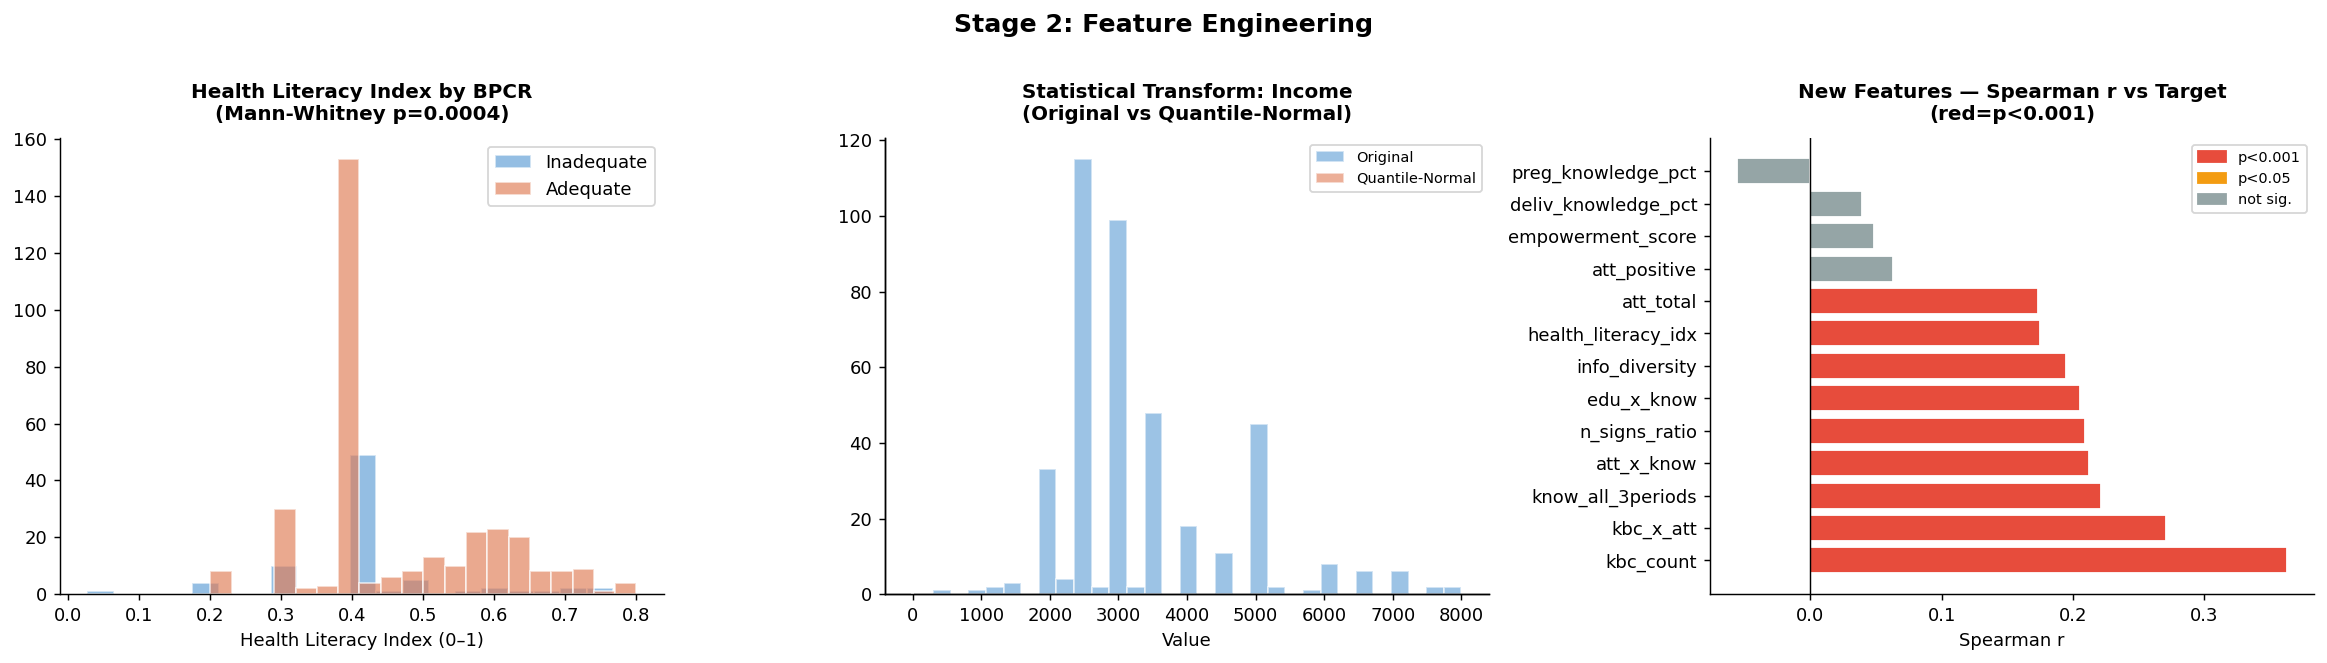

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hli_0 = X_fe['health_literacy_idx'][y_arr == 0]
hli_1 = X_fe['health_literacy_idx'][y_arr == 1]
axes[0].hist(hli_0, bins=20, alpha=0.65, color=PALETTE[0], label='Inadequate', edgecolor='white')
axes[0].hist(hli_1, bins=20, alpha=0.65, color=PALETTE[1], label='Adequate',   edgecolor='white')
_, pv_hli = stats.mannwhitneyu(hli_0, hli_1)
axes[0].set_title(f'Health Literacy Index by BPCR\n(Mann-Whitney p={pv_hli:.4f})')
axes[0].legend(); axes[0].set_xlabel('Health Literacy Index (0–1)')

axes[1].hist(X_fe['income'], bins=30, alpha=0.6, color=PALETTE[0], label='Original', edgecolor='white')
ax_twin = axes[1].twinx()
ax_twin.hist(X_fe['qt_income'], bins=30, alpha=0.6, color=PALETTE[1], label='Quantile-Normal', edgecolor='white')
ax_twin.set_yticks([])
l1, la1 = axes[1].get_legend_handles_labels()
l2, la2 = ax_twin.get_legend_handles_labels()
axes[1].legend(l1+l2, la1+la2, fontsize=8)
axes[1].set_title('Statistical Transform: Income\n(Original vs Quantile-Normal)')
axes[1].set_xlabel('Value')

new_feats_corr = ['health_literacy_idx','empowerment_score','know_all_3periods',
                  'info_diversity','kbc_count','att_total','att_positive',
                  'edu_x_know','att_x_know','kbc_x_att','n_signs_ratio',
                  'preg_knowledge_pct','deliv_knowledge_pct']
new_feats_corr = [c for c in new_feats_corr if c in X_fe.columns]
nc_vals = {col: stats.spearmanr(X_fe[col], y_arr) for col in new_feats_corr}
nc_df = pd.DataFrame({'r': {k: v[0] for k, v in nc_vals.items()},
                       'p': {k: v[1] for k, v in nc_vals.items()}}).sort_values('r', ascending=False)
c_nc = ['#E74C3C' if p < 0.001 else ('#F39C12' if p < 0.05 else '#95A5A6') for p in nc_df['p']]
axes[2].barh(nc_df.index, nc_df['r'], color=c_nc, edgecolor='white')
axes[2].axvline(0, color='black', lw=0.8)
axes[2].set_title('New Features — Spearman r vs Target\n(red=p<0.001)')
axes[2].set_xlabel('Spearman r')
legend_c = [mpatches.Patch(color='#E74C3C', label='p<0.001'),
            mpatches.Patch(color='#F39C12', label='p<0.05'),
            mpatches.Patch(color='#95A5A6', label='not sig.')]
axes[2].legend(handles=legend_c, fontsize=8)

plt.suptitle('Stage 2: Feature Engineering', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Feature Stability Analysis (10 seeds)

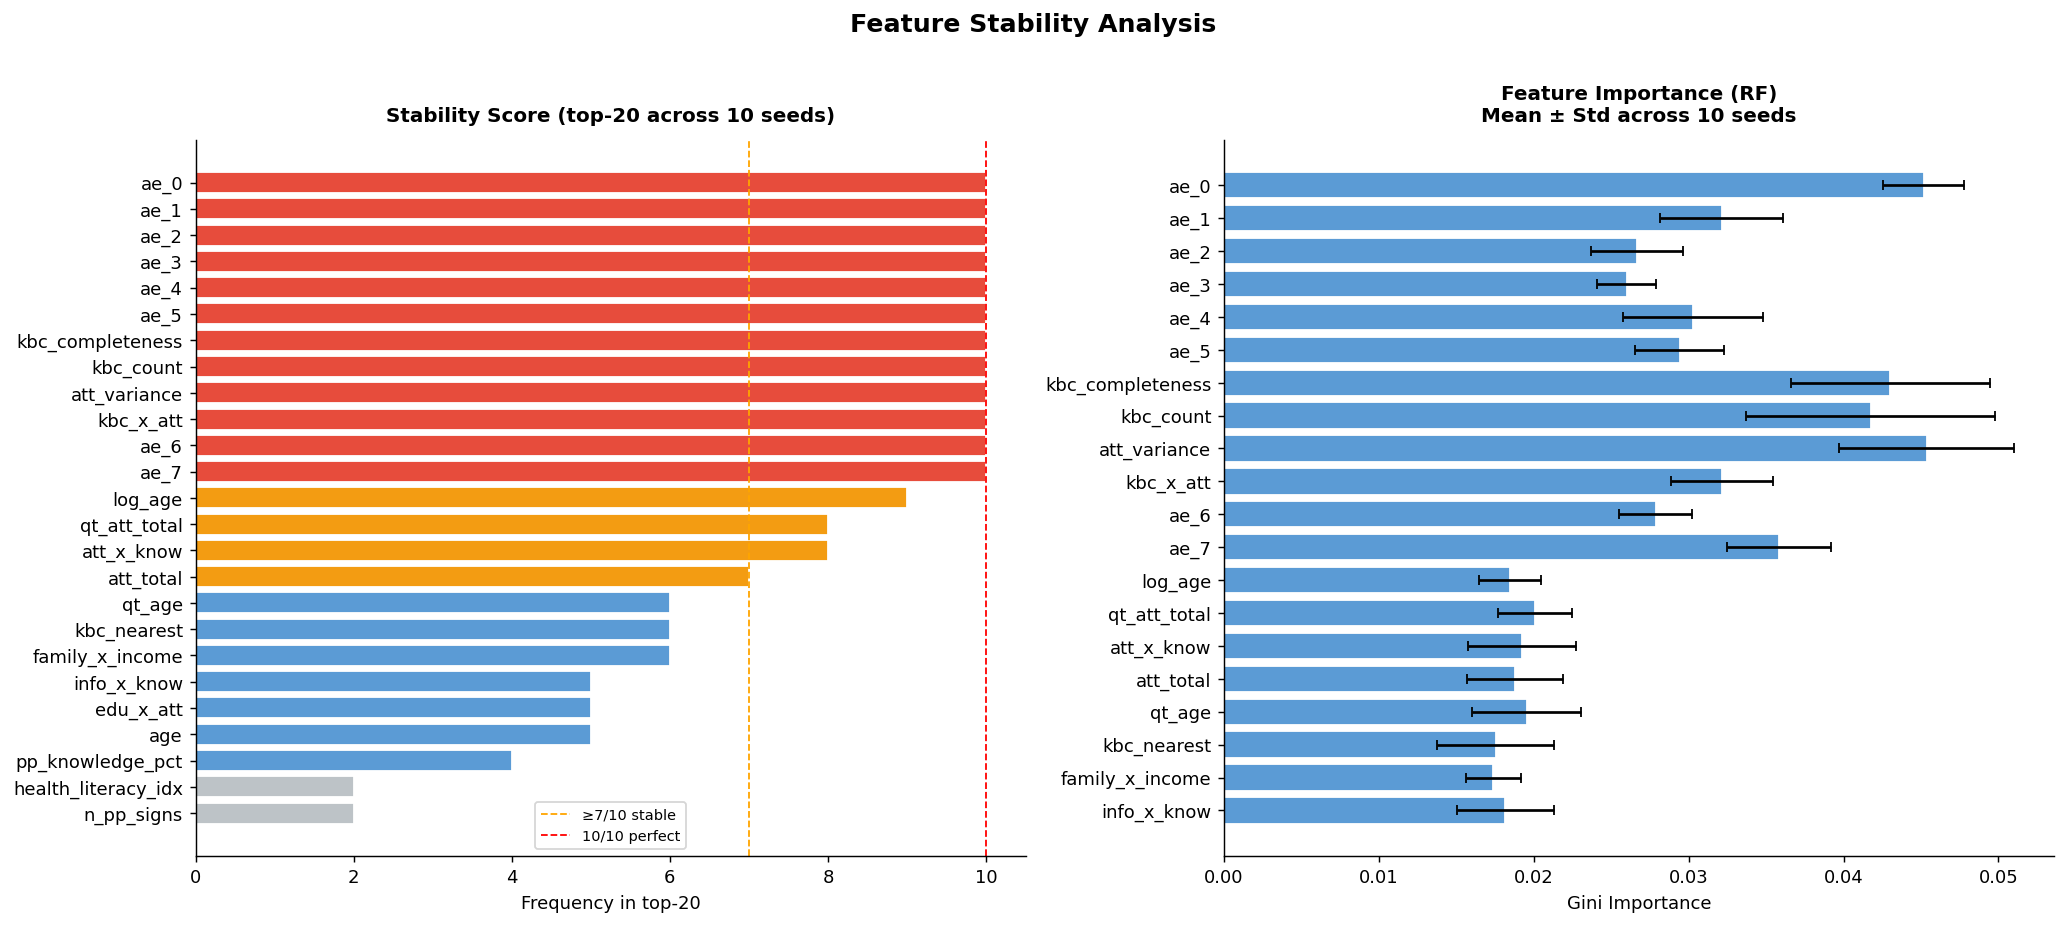

Stable features (≥8/10 seeds):
['ae_0', 'ae_1', 'ae_2', 'ae_3', 'ae_4', 'ae_5', 'kbc_completeness', 'kbc_count', 'att_variance', 'kbc_x_att', 'ae_6', 'ae_7', 'log_age', 'qt_att_total', 'att_x_know']


In [11]:
SEEDS = [0, 7, 13, 21, 42, 99, 123, 256, 512, 777]
K_TOP = 20

stability_counts    = np.zeros(len(all_feat_names), dtype=int)
importance_matrix   = np.zeros((len(SEEDS), len(all_feat_names)))

for s_idx, seed in enumerate(SEEDS):
    rf = RandomForestClassifier(n_estimators=100, max_depth=8,
                                class_weight='balanced', random_state=seed)
    rf.fit(X_all, y_arr)
    imp = rf.feature_importances_
    importance_matrix[s_idx] = imp
    for idx in np.argsort(imp)[::-1][:K_TOP]:
        stability_counts[idx] += 1

stability_df = pd.DataFrame({
    'feature':   all_feat_names,
    'stability': stability_counts,
    'imp_mean':  importance_matrix.mean(axis=0),
    'imp_std':   importance_matrix.std(axis=0)
}).sort_values('stability', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top25 = stability_df.head(25)
c_stab = ['#E74C3C' if s == 10 else ('#F39C12' if s >= 7 else ('#5B9BD5' if s >= 4 else '#BDC3C7'))
          for s in top25['stability']]
axes[0].barh(top25['feature'][::-1], top25['stability'][::-1],
             color=c_stab[::-1], edgecolor='white')
axes[0].axvline(7,  color='orange', ls='--', lw=1, label='≥7/10 stable')
axes[0].axvline(10, color='red',    ls='--', lw=1, label='10/10 perfect')
axes[0].set_title(f'Stability Score (top-{K_TOP} across {len(SEEDS)} seeds)')
axes[0].set_xlabel(f'Frequency in top-{K_TOP}')
axes[0].legend(fontsize=8)

top20 = stability_df.head(20)
axes[1].barh(top20['feature'][::-1], top20['imp_mean'][::-1],
             xerr=top20['imp_std'][::-1], color=PALETTE[0], edgecolor='white', capsize=3)
axes[1].set_title('Feature Importance (RF)\nMean ± Std across 10 seeds')
axes[1].set_xlabel('Gini Importance')

plt.suptitle('Feature Stability Analysis', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

print('Stable features (≥8/10 seeds):')
print(stability_df[stability_df['stability'] >= 8]['feature'].tolist())

---
## Stage 3 — Feature Selection (4 Methods + Consensus)

Four independent methods are applied, each selecting top-20 features. Consensus is built at three levels (≥2, ≥3, =4 methods):

| Method | Rationale |
|--------|----------|
| **Mutual Information** | Captures non-linear dependencies; averaged over 10 seeds |
| **SHAP (TreeExplainer)** | Model-aware global importance via mean \|SHAP\| |
| **RFE** | Recursive elimination with Logistic Regression as ranker |
| **Stability Selection** | Multi-seed top-K voting — already computed above |

In [12]:
try:
    import shap
    SHAP_AVAILABLE = True
except Exception as e:
    SHAP_AVAILABLE = False
    print(f'SHAP package is not available; fallback RF importance will be used: {e}')

N_TOP = 20

print('[1/4] Mutual Information...')
mi_scores_all = np.zeros((len(SEEDS), X_all.shape[1]))
for s_idx, seed in enumerate(SEEDS):
    mi_scores_all[s_idx] = mutual_info_classif(X_all, y_arr, random_state=seed)
mi_mean = mi_scores_all.mean(axis=0)
mi_std  = mi_scores_all.std(axis=0)
mi_rank = pd.Series(mi_mean, index=all_feat_names).sort_values(ascending=False)
mi_top  = set(mi_rank.head(N_TOP).index)
print(f'  Top-5: {list(mi_rank.head(5).index)}')

print('[2/4] SHAP...')
rf_for_shap = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_for_shap.fit(X_all, y_arr)
if SHAP_AVAILABLE:
    explainer   = shap.TreeExplainer(rf_for_shap)
    shap_values = explainer.shap_values(X_all)
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        sv = shap_values[:, :, 1] if shap_values.shape[2] == 2 else shap_values[1]
        sv = sv.T if sv.shape[0] != len(y_arr) else sv
    elif isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    if sv.ndim != 2 or sv.shape[1] != X_all.shape[1]:
        sv = np.array(shap_values)[1] if len(np.array(shap_values)) == 2 else np.abs(np.array(shap_values)).mean(axis=0)
    shap_importance = np.abs(sv).mean(axis=0)
else:
    sv = np.tile(rf_for_shap.feature_importances_, (X_all.shape[0], 1))
    shap_importance = rf_for_shap.feature_importances_
shap_rank = pd.Series(shap_importance, index=all_feat_names).sort_values(ascending=False)
shap_top  = set(shap_rank.head(N_TOP).index)
print(f'  Top-5: {list(shap_rank.head(5).index)}')

print('[3/4] RFE...')
X_rfe  = StandardScaler().fit_transform(X_all)
lr_rfe = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42)
rfe    = RFE(estimator=lr_rfe, n_features_to_select=N_TOP, step=3)
rfe.fit(X_rfe, y_arr)
rfe_ranking = pd.Series(rfe.ranking_, index=all_feat_names).sort_values()
rfe_top     = set(rfe_ranking[rfe_ranking == 1].index)
print(f'  Top-5: {list(rfe_ranking.head(5).index)}')

print('[4/4] Stability Selection (from Stage 2)...')
stab_top = set(stability_df.head(N_TOP)['feature'].tolist())

all_tops  = [mi_top, shap_top, rfe_top, stab_top]
vote_cnt  = Counter()
for method_top in all_tops:
    for feat in method_top:
        vote_cnt[feat] += 1

consensus_all = pd.Series(vote_cnt).sort_values(ascending=False)
consensus_2   = [f for f, cnt in consensus_all.items() if cnt >= 2]
consensus_3   = [f for f, cnt in consensus_all.items() if cnt >= 3]
consensus_4   = [f for f, cnt in consensus_all.items() if cnt == 4]

consensus_idx_2 = [all_feat_names.index(f) for f in consensus_2 if f in all_feat_names]
consensus_idx_3 = [all_feat_names.index(f) for f in consensus_3 if f in all_feat_names]
X_consensus2 = X_all[:, consensus_idx_2]
X_consensus3 = X_all[:, consensus_idx_3]

print(f'\n  ≥2 methods: {len(consensus_2)} features')
print(f'  ≥3 methods: {len(consensus_3)} features')
print(f'  =4 methods: {len(consensus_4)} features: {consensus_4}')

[1/4] Mutual Information...


  Top-5: ['kbc_completeness', 'kbc_x_att', 'kbc_count', 'kbc_nearest', 'info_x_know']
[2/4] SHAP...


  Top-5: ['kbc_count', 'kbc_completeness', 'att_variance', 'ae_0', 'kbc_x_att']
[3/4] RFE...
  Top-5: ['income', 'edu_women_ord', 'know_preg_danger', 'know_deliv_danger', 'k_vaginal_bleeding']
[4/4] Stability Selection (from Stage 2)...

  ≥2 methods: 24 features
  ≥3 methods: 10 features
  =4 methods: 6 features: ['kbc_completeness', 'kbc_x_att', 'kbc_count', 'att_variance', 'att_total', 'qt_att_total']


### 3.1 Feature Selection Visualizations

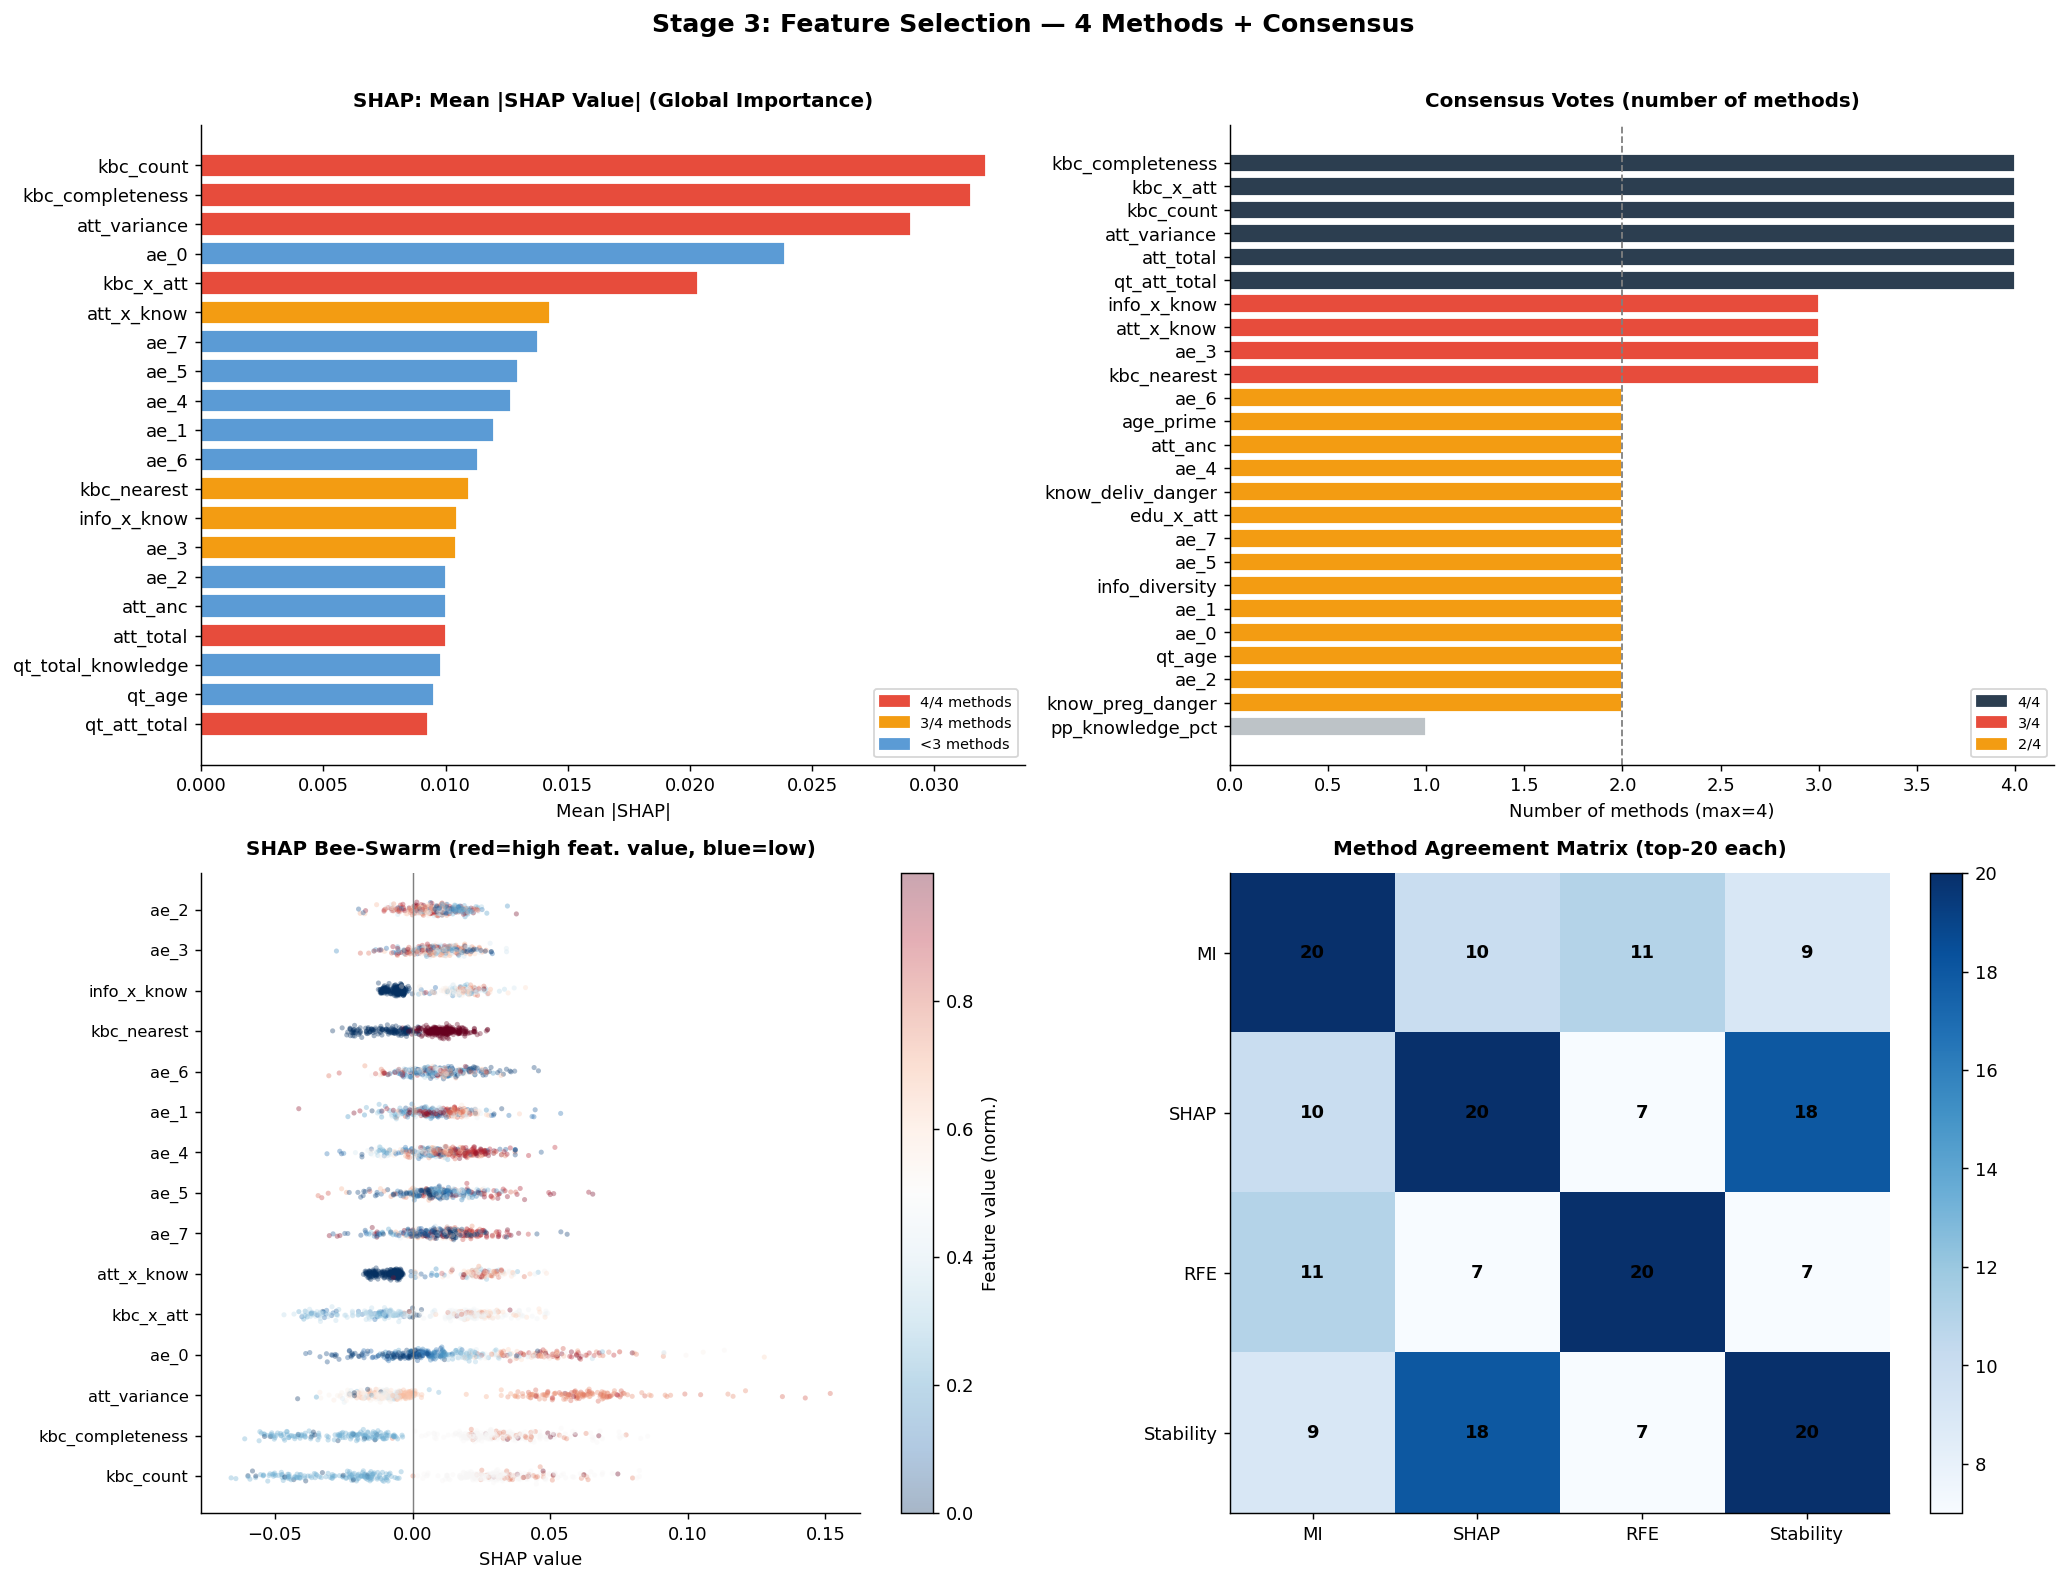

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

shap_top20 = shap_rank.head(20)
c_shap = ['#E74C3C' if f in consensus_4 else ('#F39C12' if f in consensus_3 else '#5B9BD5')
          for f in shap_top20.index]
axes[0,0].barh(shap_top20.index[::-1], shap_top20.values[::-1], color=c_shap[::-1], edgecolor='white')
axes[0,0].set_title('SHAP: Mean |SHAP Value| (Global Importance)')
axes[0,0].set_xlabel('Mean |SHAP|')
leg_c = [mpatches.Patch(color='#E74C3C', label='4/4 methods'),
         mpatches.Patch(color='#F39C12', label='3/4 methods'),
         mpatches.Patch(color='#5B9BD5', label='<3 methods')]
axes[0,0].legend(handles=leg_c, fontsize=8)

top_for_heatmap = consensus_all.head(25)
colors_vote = ['#2C3E50' if v == 4 else ('#E74C3C' if v == 3 else ('#F39C12' if v == 2 else '#BDC3C7'))
               for v in top_for_heatmap.values]
axes[0,1].barh(top_for_heatmap.index[::-1], top_for_heatmap.values[::-1],
               color=colors_vote[::-1], edgecolor='white')
axes[0,1].axvline(2, color='gray', ls='--', lw=1)
axes[0,1].set_title('Consensus Votes (number of methods)')
axes[0,1].set_xlabel('Number of methods (max=4)')
cons_leg = [mpatches.Patch(color='#2C3E50', label='4/4'),
            mpatches.Patch(color='#E74C3C', label='3/4'),
            mpatches.Patch(color='#F39C12', label='2/4')]
axes[0,1].legend(handles=cons_leg, fontsize=8)

top15_idx  = [all_feat_names.index(f) for f in shap_rank.head(15).index if f in all_feat_names]
sv_top15   = sv[:, top15_idx]
feat_top15 = [all_feat_names[i] for i in top15_idx]
X_top15    = X_all[:, top15_idx]
for j in range(sv_top15.shape[1]):
    fv     = X_top15[:, j]
    fv_n   = (fv - fv.min()) / (fv.max() - fv.min() + 1e-8)
    jitter = np.random.normal(0, 0.06, len(sv_top15))
    scatter = axes[1,0].scatter(sv_top15[:, j], j + jitter,
                                c=fv_n, cmap='RdBu_r', alpha=0.35, s=8, linewidths=0)
axes[1,0].axvline(0, color='gray', lw=0.8)
axes[1,0].set_yticks(range(len(feat_top15)))
axes[1,0].set_yticklabels(feat_top15, fontsize=9)
axes[1,0].set_xlabel('SHAP value')
axes[1,0].set_title('SHAP Bee-Swarm (red=high feat. value, blue=low)')
plt.colorbar(scatter, ax=axes[1,0], label='Feature value (norm.)')

method_names = ['MI', 'SHAP', 'RFE', 'Stability']
method_sets  = [mi_top, shap_top, rfe_top, stab_top]
overlap_mat  = np.array([[len(a & b) for b in method_sets] for a in method_sets], dtype=float)
im = axes[1,1].imshow(overlap_mat, cmap='Blues', aspect='auto')
axes[1,1].set_xticks(range(4)); axes[1,1].set_yticks(range(4))
axes[1,1].set_xticklabels(method_names); axes[1,1].set_yticklabels(method_names)
for i in range(4):
    for j in range(4):
        axes[1,1].text(j, i, f'{int(overlap_mat[i,j])}', ha='center', va='center', fontweight='bold')
axes[1,1].set_title(f'Method Agreement Matrix (top-{N_TOP} each)')
plt.colorbar(im, ax=axes[1,1])

plt.suptitle('Stage 3: Feature Selection — 4 Methods + Consensus', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Stage 4 — Target Analysis & Class Imbalance

### 4.1 BPCR Score Deep Analysis

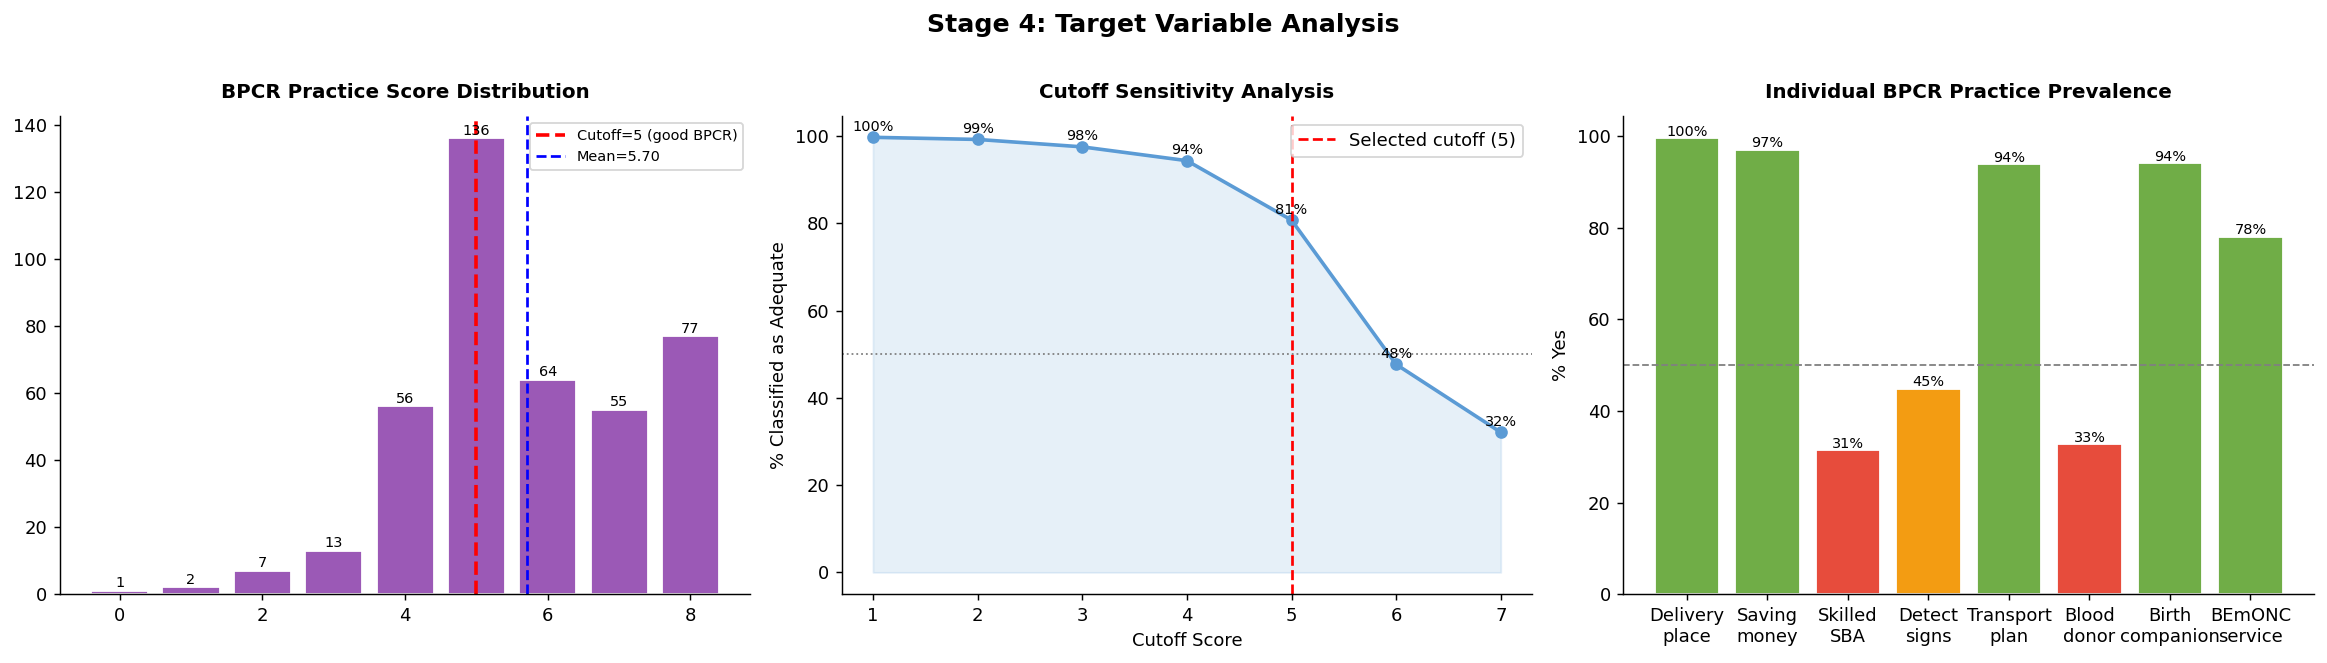

In [14]:
score_vals = df['bpcr_score'].values
prac_labels = {'p_place':'Delivery\nplace','p_money':'Saving\nmoney',
               'p_sba':'Skilled\nSBA','p_signs':'Detect\nsigns',
               'p_transport':'Transport\nplan','p_blood':'Blood\ndonor',
               'p_companion':'Birth\ncompanion','p_bemOnc':'BEmONC\nservice'}
prac_items_vis = [c for c in prac_labels if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(score_vals, bins=np.arange(-0.5, 9.5),
             color=PALETTE[3], edgecolor='white', rwidth=0.8)
axes[0].axvline(5, color='red', ls='--', lw=2, label='Cutoff=5 (good BPCR)')
axes[0].axvline(np.mean(score_vals), color='blue', ls='--', lw=1.5,
                label=f'Mean={np.mean(score_vals):.2f}')
for xi in range(0, 9):
    cnt = (score_vals == xi).sum()
    if cnt > 0:
        axes[0].text(xi, cnt+1, str(cnt), ha='center', fontsize=8)
axes[0].set_title('BPCR Practice Score Distribution'); axes[0].legend(fontsize=8)

for_cutoff = {cut: (score_vals >= cut).sum()/len(score_vals)*100 for cut in range(1, 8)}
cuts, adq_pcts = list(for_cutoff.keys()), list(for_cutoff.values())
axes[1].plot(cuts, adq_pcts, marker='o', color=PALETTE[0], lw=2)
axes[1].axvline(5, color='red', ls='--', lw=1.5, label='Selected cutoff (5)')
axes[1].axhline(50, color='gray', ls=':', lw=1)
axes[1].fill_between(cuts, adq_pcts, alpha=0.15, color=PALETTE[0])
for c, p in zip(cuts, adq_pcts):
    axes[1].text(c, p+1.5, f'{p:.0f}%', ha='center', fontsize=8)
axes[1].set_title('Cutoff Sensitivity Analysis')
axes[1].set_xlabel('Cutoff Score'); axes[1].set_ylabel('% Classified as Adequate')
axes[1].legend()

prac_pcts  = [df[c].mean()*100 for c in prac_items_vis]
prac_lbls  = [prac_labels[c] for c in prac_items_vis]
c_prac     = [PALETTE[2] if p > 70 else ('#F39C12' if p > 40 else '#E74C3C') for p in prac_pcts]
bars_p = axes[2].bar(prac_lbls, prac_pcts, color=c_prac, edgecolor='white')
axes[2].axhline(50, color='gray', ls='--', lw=1)
axes[2].set_title('Individual BPCR Practice Prevalence')
axes[2].set_ylabel('% Yes')
for bar, p in zip(bars_p, prac_pcts):
    axes[2].text(bar.get_x()+bar.get_width()/2, p+0.5, f'{p:.0f}%', ha='center', fontsize=8)

plt.suptitle('Stage 4: Target Variable Analysis', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Class Imbalance — 5 Strategy Comparison

In [15]:
def adaptive_smote(X, y, seed=42):
    rng = np.random.RandomState(seed)
    classes, cnts = np.unique(y, return_counts=True)
    if cnts.min() == cnts.max():
        return X, y
    min_cls = classes[np.argmin(cnts)]
    X_min   = X[y == min_cls]
    n_add   = cnts.max() - cnts.min()
    feat_std = X_min.std(axis=0) + 1e-8
    synthetic = []
    for _ in range(n_add):
        i, j        = rng.choice(len(X_min), 2, replace=False)
        alpha       = rng.uniform(0.15, 0.85)
        noise_scale = rng.uniform(0.03, 0.15)
        synthetic.append(alpha * X_min[i] + (1 - alpha) * X_min[j]
                         + rng.normal(0, noise_scale * feat_std))
    X_s = np.vstack([X, np.array(synthetic)])
    y_s = np.concatenate([y, np.full(n_add, min_cls)])
    idx = rng.permutation(len(y_s))
    return X_s[idx], y_s[idx]

def simple_smote(X, y, k=5, seed=42):
    rng = np.random.RandomState(seed)
    classes, cnts = np.unique(y, return_counts=True)
    if cnts.min() == cnts.max():
        return X, y
    min_cls = classes[np.argmin(cnts)]
    X_min   = X[y == min_cls]
    n_add   = cnts.max() - cnts.min()
    nn      = NearestNeighbors(n_neighbors=min(k+1, len(X_min))).fit(X_min)
    _, indices = nn.kneighbors(X_min)
    synthetic = []
    for _ in range(n_add):
        idx_i = rng.randint(0, len(X_min))
        idx_j = rng.choice(indices[idx_i][1:])
        alpha = rng.random()
        synthetic.append(X_min[idx_i] + alpha * (X_min[idx_j] - X_min[idx_i]))
    X_s = np.vstack([X, np.array(synthetic)])
    y_s = np.concatenate([y, np.full(n_add, min_cls)])
    idx = rng.permutation(len(y_s))
    return X_s[idx], y_s[idx]

def smote_enn(X, y, k=5, seed=42):
    X_s, y_s = simple_smote(X, y, k=k, seed=seed)
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_s, y_s)
    keep = (knn.predict(X_s) == y_s)
    return X_s[keep], y_s[keep]

def eval_imbalance_strategy(name, X, y, oversample_fn=None,
                             use_class_weight=False, seeds=[42, 7, 13]):
    all_metrics = {k: [] for k in ['f1', 'precision', 'recall', 'roc_auc']}
    cw = 'balanced' if use_class_weight else None
    for seed in seeds:
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr_idx, te_idx in skf.split(X, y):
            X_tr, X_te = X[tr_idx], X[te_idx]
            y_tr, y_te = y[tr_idx], y[te_idx]
            if oversample_fn is not None:
                X_tr, y_tr = oversample_fn(X_tr, y_tr, seed=seed)
            clf = HistGradientBoostingClassifier(
                max_iter=100, random_state=42,
                class_weight=cw if cw else None)
            clf.fit(X_tr, y_tr)
            y_pred = clf.predict(X_te)
            y_prob = clf.predict_proba(X_te)[:, 1]
            all_metrics['f1'].append(f1_score(y_te, y_pred, zero_division=0))
            all_metrics['precision'].append(precision_score(y_te, y_pred, zero_division=0))
            all_metrics['recall'].append(recall_score(y_te, y_pred, zero_division=0))
            try:
                all_metrics['roc_auc'].append(roc_auc_score(y_te, y_prob))
            except:
                all_metrics['roc_auc'].append(0.5)
    result = {k: {'mean': np.mean(v), 'std': np.std(v)} for k, v in all_metrics.items()}
    print(f"  {name:28s}: F1={result['f1']['mean']:.4f}±{result['f1']['std']:.4f}  "
          f"AUC={result['roc_auc']['mean']:.4f}  Recall={result['recall']['mean']:.4f}")
    return result

print('=== Class Imbalance Strategy Comparison (3 seeds × 5-fold CV) ===')
X_eval = X_consensus2

imb_results = {}
imb_results['No resampling']        = eval_imbalance_strategy('No resampling',        X_eval, y_arr)
imb_results['Class weight balanced']= eval_imbalance_strategy('Class weight balanced', X_eval, y_arr, use_class_weight=True)
imb_results['SMOTE (standard)']     = eval_imbalance_strategy('SMOTE (standard)',      X_eval, y_arr, oversample_fn=simple_smote)
imb_results['SMOTE-ENN']            = eval_imbalance_strategy('SMOTE-ENN',             X_eval, y_arr, oversample_fn=smote_enn)
imb_results['Adaptive Noise (novel)']= eval_imbalance_strategy('Adaptive Noise (novel)',X_eval, y_arr, oversample_fn=adaptive_smote)

best_strat = max(imb_results, key=lambda k: imb_results[k]['roc_auc']['mean'])
print(f'\n→ Best strategy: {best_strat}')

=== Class Imbalance Strategy Comparison (3 seeds × 5-fold CV) ===


  No resampling               : F1=0.8840±0.0171  AUC=0.7446  Recall=0.9278


  Class weight balanced       : F1=0.8652±0.0233  AUC=0.7491  Recall=0.8766


  SMOTE (standard)            : F1=0.8679±0.0180  AUC=0.7600  Recall=0.8785


  SMOTE-ENN                   : F1=0.8318±0.0262  AUC=0.7602  Recall=0.7891


  Adaptive Noise (novel)      : F1=0.8808±0.0137  AUC=0.7596  Recall=0.9137

→ Best strategy: SMOTE-ENN


### 4.3 Imbalance Strategy Comparison Visualization

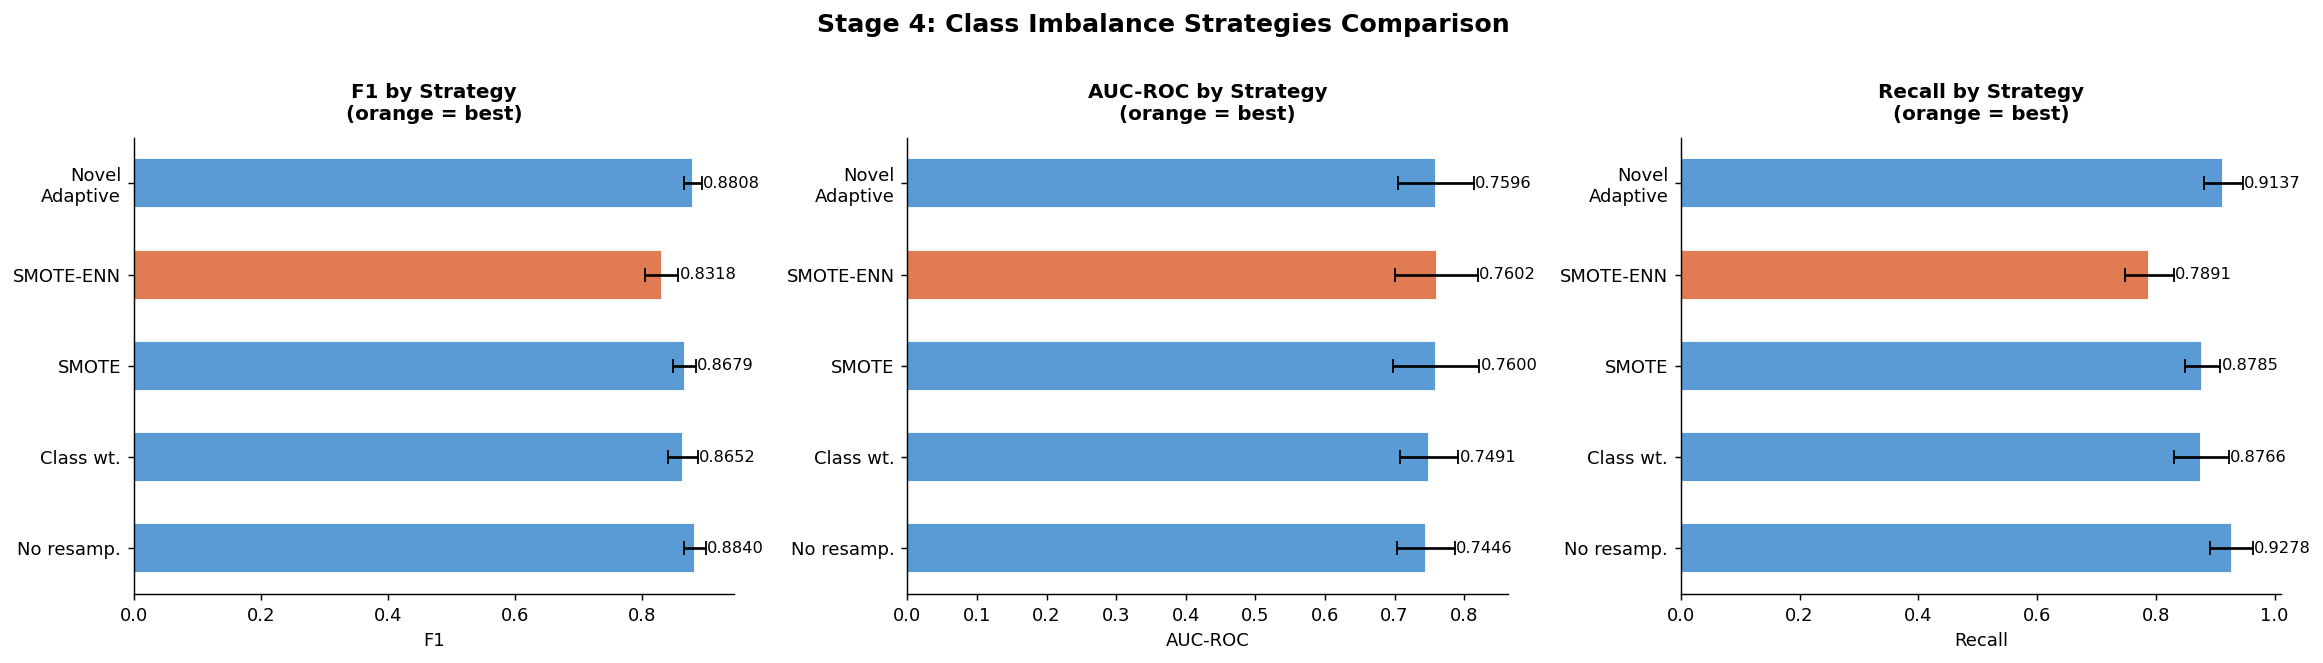

In [16]:
strat_names = list(imb_results.keys())
shorts = ['No resamp.', 'Class wt.', 'SMOTE', 'SMOTE-ENN', 'Novel\nAdaptive']
c_strats = [PALETTE[1] if n == best_strat else PALETTE[0] for n in strat_names]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, label in zip(axes, ['f1', 'roc_auc', 'recall'], ['F1', 'AUC-ROC', 'Recall']):
    means = [imb_results[n][metric]['mean'] for n in strat_names]
    stds  = [imb_results[n][metric]['std']  for n in strat_names]
    ax.barh(shorts, means, xerr=stds, color=c_strats, edgecolor='white', capsize=4, height=0.55)
    ax.set_title(f'{label} by Strategy\n(orange = best)')
    ax.set_xlabel(label)
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(m+s+0.002, i, f'{m:.4f}', va='center', fontsize=9)

plt.suptitle('Stage 4: Class Imbalance Strategies Comparison', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Stages 1–4 Summary Dashboard

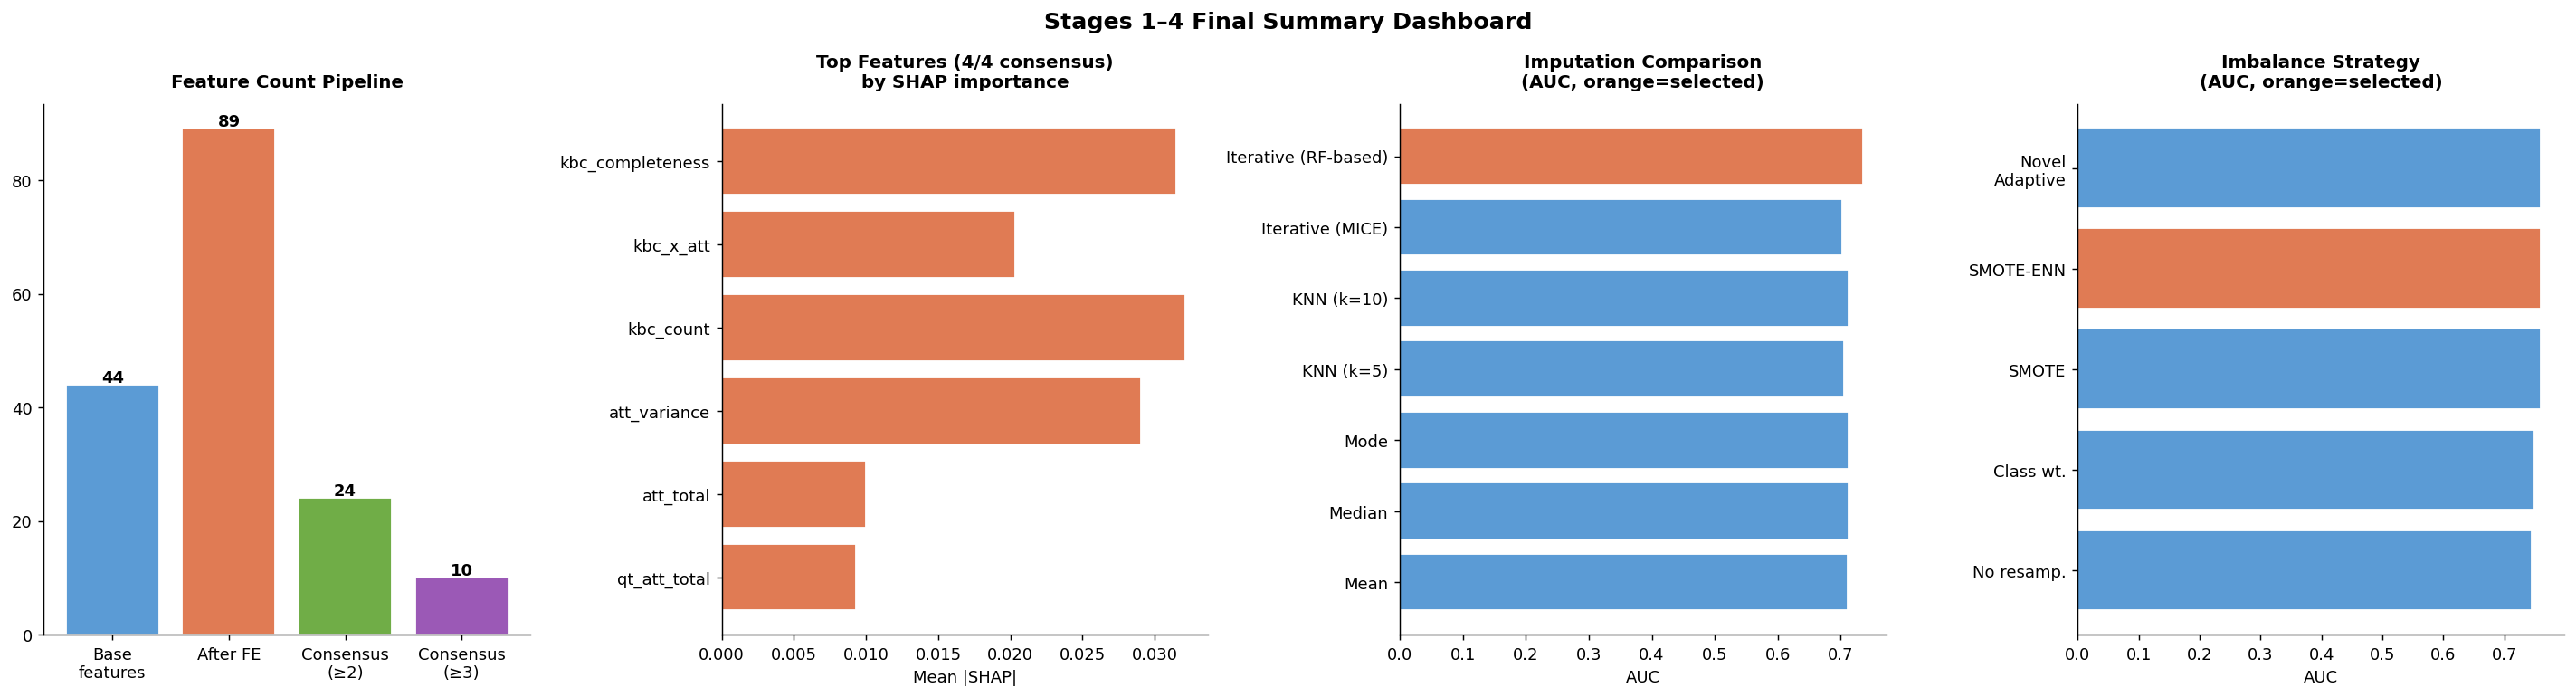

✓ STAGES 1–4 COMPLETE
  Samples:                411
  Features (ML-ready):    89
  Consensus (≥2 methods): 24
  Consensus (=4 methods): 6
  Best imputation:        Iterative (RF-based)
  Best imbalance strategy:SMOTE-ENN
  pipeline_state.pkl:     saved
→ NEXT: Stage 5 — Modern ML Models


In [17]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

stage_labels = ['Base\nfeatures', 'After FE', 'Consensus\n(≥2)', 'Consensus\n(≥3)']
stage_counts = [len(numeric_features), len(all_feat_names), X_consensus2.shape[1], X_consensus3.shape[1]]
bars_st = axes[0].bar(stage_labels, stage_counts, color=PALETTE[:4], edgecolor='white')
for bar, v in zip(bars_st, stage_counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Feature Count Pipeline')

top14 = consensus_4
axes[1].barh(top14[::-1], [shap_rank.get(f, 0) for f in top14[::-1]],
             color=PALETTE[1], edgecolor='white')
axes[1].set_title('Top Features (4/4 consensus)\nby SHAP importance')
axes[1].set_xlabel('Mean |SHAP|')

c_imp = [PALETTE[1] if n == best_method['name'] else PALETTE[0] for n in names]
axes[2].barh(names, aucm, color=c_imp, edgecolor='white')
axes[2].set_title('Imputation Comparison\n(AUC, orange=selected)')
axes[2].set_xlabel('AUC')

imb_auc = [imb_results[n]['roc_auc']['mean'] for n in strat_names]
c_imb   = [PALETTE[1] if n == best_strat else PALETTE[0] for n in strat_names]
axes[3].barh(shorts, imb_auc, color=c_imb, edgecolor='white')
axes[3].set_title('Imbalance Strategy\n(AUC, orange=selected)')
axes[3].set_xlabel('AUC')

plt.suptitle('Stages 1–4 Final Summary Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

import joblib
pipeline_state = {
    'X_full':              X_all,
    'X_consensus2':        X_consensus2,
    'X_consensus3':        X_consensus3,
    'y':                   y_arr,
    'feature_names_full':  all_feat_names,
    'feature_names_c2':    consensus_2,
    'feature_names_c3':    consensus_3,
    'consensus_4':         consensus_4,
    'oversample_fn':       adaptive_smote,
    'best_imputer':        best_method['name'],
    'shap_importance':     shap_rank.to_dict(),
}
joblib.dump(pipeline_state, 'pipeline_state.pkl')

print('=' * 55)
print('✓ STAGES 1–4 COMPLETE')
print('=' * 55)
print(f'  Samples:                411')
print(f'  Features (ML-ready):    {X_all.shape[1]}')
print(f'  Consensus (≥2 methods): {X_consensus2.shape[1]}')
print(f'  Consensus (=4 methods): {len(consensus_4)}')
print(f'  Best imputation:        {best_method["name"]}')
print(f'  Best imbalance strategy:{best_strat}')
print(f'  pipeline_state.pkl:     saved')
print('=' * 55)
print('→ NEXT: Stage 5 — Modern ML Models')

## Stage 5 - Modern ML Models, Novel Component and Robust Evaluation

From here the notebook continues directly from the cleaned and engineered feature matrix created above. No second dataset loading is used.

Modern models include HGBC, XGBoost, LightGBM, CatBoost, and Neural Network. The novel component is evaluated through class imbalance strategies, calibration, learning curves, and decision-threshold analysis. The work keeps one target definition throughout: **good BPCR = BPCR score >= 5 out of 8**.

### 5.0 Stage 5 Overview

This section closes the final PDF requirements in one continuous pipeline:
- **Point 5:** CatBoost is evaluated with the other modern models.
- **Point 7/12:** learning curves and running time are analysed.
- **Point 8/9:** probability calibration and decision threshold analysis support explainability and error analysis.


### 5.1 Connect Clean Feature Matrix and Target

In [18]:
# Install missing packages
!pip install -q catboost shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, learning_curve, cross_val_predict, train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    brier_score_loss, precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

# Connect to the clean feature matrix created in Stages 1-4.
# The duplicated second loading block was removed, so this section uses the prepared matrices directly.
if 'X_consensus2' in globals() and 'consensus_2' in globals() and len(consensus_2) == X_consensus2.shape[1]:
    X = pd.DataFrame(X_consensus2, columns=consensus_2)
    print(f'Using consensus feature matrix X_consensus2: {X.shape}')
elif 'X_all' in globals() and 'all_feat_names' in globals():
    X = pd.DataFrame(X_all, columns=all_feat_names)
    print(f'Using full engineered feature matrix X_all: {X.shape}')
elif 'X_clean' in globals() and 'feature_names' in globals():
    X = pd.DataFrame(X_clean, columns=feature_names)
    print(f'Using cleaned feature matrix X_clean: {X.shape}')
else:
    raise RuntimeError('Prepared feature matrix not found. Run Stages 1-4 first.')

y = pd.Series(y_arr, name='good_bpcr_practice')
print(f'Using y_arr target: {y.shape}')

try:
    RANDOM_STATE
except NameError:
    RANDOM_STATE = 42
    print('RANDOM_STATE was not set -> using 42')

try:
    cv
except NameError:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    print('cv was not set -> StratifiedKFold(5)')

# ============================================================
# Auto-encoding of categorical columns
# Makes X and X_arr fully numeric (via OneHotEncoder),
# so the pipeline with SimpleImputer(median) works without errors.
# ============================================================
if hasattr(X, 'select_dtypes'):
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    if cat_cols:
        print(f'Found {len(cat_cols)} categorical columns, applying one-hot encoding...')
        X = pd.get_dummies(X, columns=cat_cols, dummy_na=False).astype(float)
        print(f'New X shape: {X.shape}')
    else:
        print('No categorical columns, X is already numeric')
else:
    X = pd.DataFrame(X).astype(float)

X_arr = X.values
y_arr = np.array(y).astype(int)
feature_names = list(X.columns)
print('Ready: X (DataFrame), X_arr (numpy), y_arr — all numeric')

Using consensus feature matrix X_consensus2: (411, 24)
Using y_arr target: (411,)
RANDOM_STATE was not set -> using 42
cv was not set -> StratifiedKFold(5)
No categorical columns, X is already numeric
Ready: X (DataFrame), X_arr (numpy), y_arr — all numeric


### 5.2 CatBoost and Modern Model Comparison

CatBoost complements the trio HGBC + XGBoost + LightGBM. It offers native support for categorical features, ordered boosting (which reduces target leakage) and robust defaults. This provides a fair comparison of the four leading gradient boosting implementations.

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

def make_pipeline(clf):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('clf', clf),
    ])

models = {
    'HGBC': make_pipeline(HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, max_depth=6,
        l2_regularization=0.05, class_weight='balanced',
        random_state=RANDOM_STATE)),
    'XGBoost': make_pipeline(XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.85, colsample_bytree=0.85,
        eval_metric='logloss', use_label_encoder=False,
        random_state=RANDOM_STATE)),
    'LightGBM': make_pipeline(LGBMClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=-1,
        num_leaves=31, subsample=0.85, colsample_bytree=0.85,
        class_weight='balanced', verbose=-1,
        random_state=RANDOM_STATE)),
    'CatBoost': make_pipeline(CatBoostClassifier(
        iterations=400, learning_rate=0.05, depth=6,
        l2_leaf_reg=3.0, auto_class_weights='Balanced',
        verbose=False, random_seed=RANDOM_STATE)),
    'NeuralNetwork_MLP': make_pipeline(MLPClassifier(
        hidden_layer_sizes=(64, 32), alpha=1e-3,
        early_stopping=True, random_state=RANDOM_STATE)),
}

print('Models ready:', list(models.keys()))

Models ready: ['HGBC', 'XGBoost', 'LightGBM', 'CatBoost', 'NeuralNetwork_MLP']


In [21]:
cv_results = []

for name, pipe in models.items():
    print(f'Evaluating {name}...')
    for fold, (tr, te) in enumerate(cv.split(X_arr, y_arr)):
        t0 = time.perf_counter()
        pipe.fit(X_arr[tr], y_arr[tr])
        train_t = time.perf_counter() - t0

        t1 = time.perf_counter()
        proba = pipe.predict_proba(X_arr[te])[:, 1]
        pred  = (proba >= 0.5).astype(int)
        pred_t = time.perf_counter() - t1

        cv_results.append({
            'model': name, 'fold': fold,
            'accuracy':  accuracy_score(y_arr[te], pred),
            'precision': precision_score(y_arr[te], pred, zero_division=0),
            'recall':    recall_score(y_arr[te], pred),
            'f1':        f1_score(y_arr[te], pred),
            'auc':       roc_auc_score(y_arr[te], proba),
            'train_time_sec':   train_t,
            'predict_time_sec': pred_t,
        })

cv_df = pd.DataFrame(cv_results)
agg = cv_df.groupby('model').agg(['mean', 'std']).round(4)
print('\n=== Model Comparison (mean ± std over 5 folds) ===')
agg

Evaluating HGBC...


Evaluating XGBoost...


Evaluating LightGBM...


Evaluating CatBoost...


Evaluating NeuralNetwork_MLP...

=== Model Comparison (mean ± std over 5 folds) ===


fold         accuracy         precision          recall  \
                  mean     std     mean     std      mean     std    mean   
model                                                                       
CatBoost           2.0  1.5811   0.8248  0.0220    0.8758  0.0108  0.9126   
HGBC               2.0  1.5811   0.7689  0.0189    0.8517  0.0074  0.8645   
LightGBM           2.0  1.5811   0.7981  0.0174    0.8547  0.0048  0.9038   
NeuralNetwork_MLP  2.0  1.5811   0.8053  0.0231    0.8186  0.0196  0.9758   
XGBoost            2.0  1.5811   0.8103  0.0157    0.8475  0.0180  0.9338   

                               f1             auc         train_time_sec  \
                      std    mean     std    mean     std           mean   
model                                                                      
CatBoost           0.0326  0.8936  0.0154  0.7738  0.0365         0.4712   
HGBC               0.0297  0.8578  0.0140  0.7429  0.0290         0.1257   
LightGBM           0.0244  0.8784  0.0119  0.7400  0.0473         0.0619   
NeuralNetwork_MLP  0.0230  0.8901  0.0130  0.7144  0.1214         0.0132   
XGBoost            0.0249  0.8882  0.0095  0.7444  0.0507         0.1235   

                          predict_time_sec          
                      std             mean     std  
model                                               
CatBoost           0.0745           0.0017  0.0001  
HGBC               0.0028           0.0025  0.0001  
LightGBM           0.0046           0.0011  0.0002  
NeuralNetwork_MLP  0.0028           0.0002  0.0000  
XGBoost            0.0431           0.0014  0.0001

### 5.3 Probability Calibration

In medical tasks it is important not only to have classification accuracy, but also to ensure that the predicted probabilities reflect reality. If the model says 'risk = 70%', ideally 70% of such patients should actually have a positive outcome.

We compare three variants for each model:
- **Raw** — without calibration
- **Sigmoid** (Platt scaling) — parametric, good for small samples
- **Isotonic** — non-parametric, more flexible but requires more data

Metric — **Brier score** (the lower, the better).

In [22]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_arr, y_arr, test_size=0.25, stratify=y_arr, random_state=RANDOM_STATE
)

calibration_results = {}

for name, pipe in models.items():
    pipe.fit(X_tr, y_tr)
    p_raw = pipe.predict_proba(X_te)[:, 1]

    cal_sig = CalibratedClassifierCV(estimator=pipe, method='sigmoid', cv=3)
    cal_sig.fit(X_tr, y_tr)
    p_sig = cal_sig.predict_proba(X_te)[:, 1]

    cal_iso = CalibratedClassifierCV(estimator=pipe, method='isotonic', cv=3)
    cal_iso.fit(X_tr, y_tr)
    p_iso = cal_iso.predict_proba(X_te)[:, 1]

    calibration_results[name] = {
        'raw_brier':      brier_score_loss(y_te, p_raw),
        'sigmoid_brier':  brier_score_loss(y_te, p_sig),
        'isotonic_brier': brier_score_loss(y_te, p_iso),
        'probs': {'raw': p_raw, 'sigmoid': p_sig, 'isotonic': p_iso},
    }

brier_df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if 'brier' in kk}
                         for k, v in calibration_results.items()}).T
brier_df['best'] = brier_df.idxmin(axis=1).str.replace('_brier', '')
print('=== Brier score (lower = better) ===')
brier_df.round(4)

=== Brier score (lower = better) ===


,raw_brier,sigmoid_brier,isotonic_brier,best
HGBC,0.2037,0.1515,0.1633,sigmoid
XGBoost,0.1777,0.1458,0.1464,sigmoid
LightGBM,0.2132,0.1485,0.1571,sigmoid
CatBoost,0.1781,0.1416,0.1494,sigmoid
NeuralNetwork_MLP,0.1898,0.1556,0.1597,sigmoid


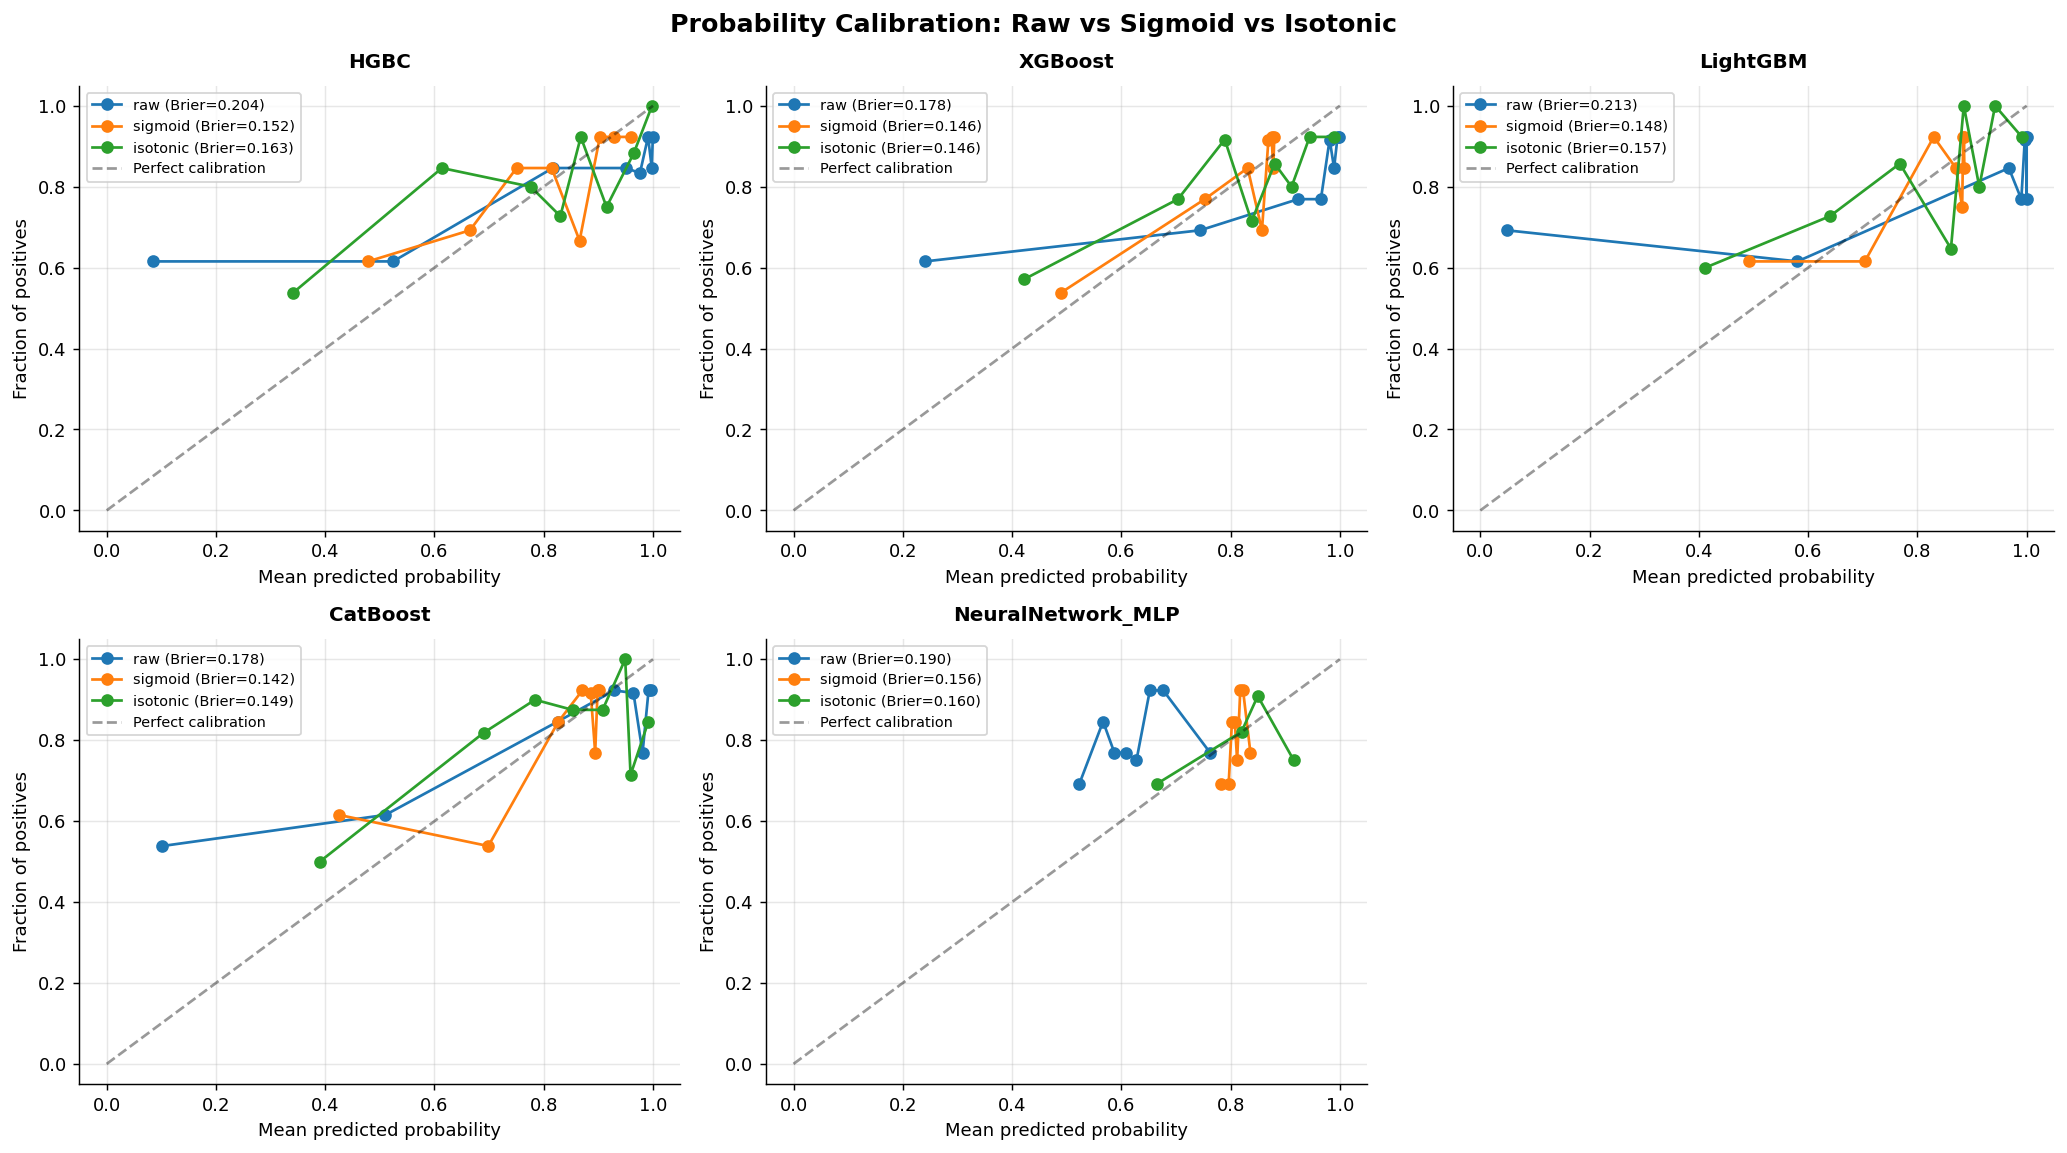

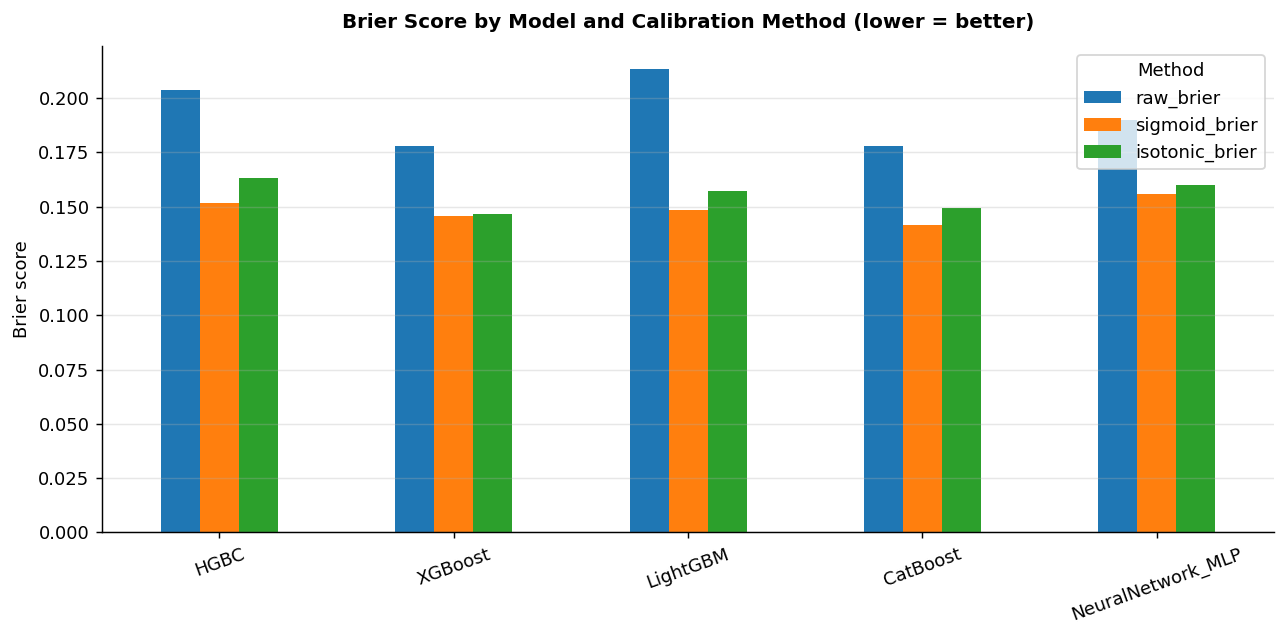

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, (name, info) in zip(axes, calibration_results.items()):
    for label, p in info['probs'].items():
        frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=8, strategy='quantile')
        ax.plot(mean_pred, frac_pos, marker='o', label=f'{label} (Brier={brier_score_loss(y_te, p):.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
    ax.set_title(f'{name}')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for i in range(len(calibration_results), len(axes)):
    axes[i].axis('off')

plt.suptitle('Probability Calibration: Raw vs Sigmoid vs Isotonic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
brier_df[['raw_brier', 'sigmoid_brier', 'isotonic_brier']].plot(kind='bar', ax=ax)
ax.set_title('Brier Score by Model and Calibration Method (lower = better)')
ax.set_ylabel('Brier score')
ax.legend(title='Method')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Clinical interpretation.** Calibration matters more to a clinician than accuracy: if the model outputs '30% risk' but in reality 60% of such patients have the outcome, the doctor will make the wrong decision. Sigmoid / Isotonic correct the systematic shift of boosting probabilities (they are usually overconfident at the 0 and 1 extremes).

### 5.4 Learning Curves and Stability

A learning curve shows how train and validation metrics change as the training sample grows. It diagnoses two fundamental problems:

- **Large train–val gap** → overfitting → need regularisation / fewer features
- **Both curves are low and flat** → underfitting → need a more complex model / more features
- **Curves converge and plateau** → model is saturated, more data will not help

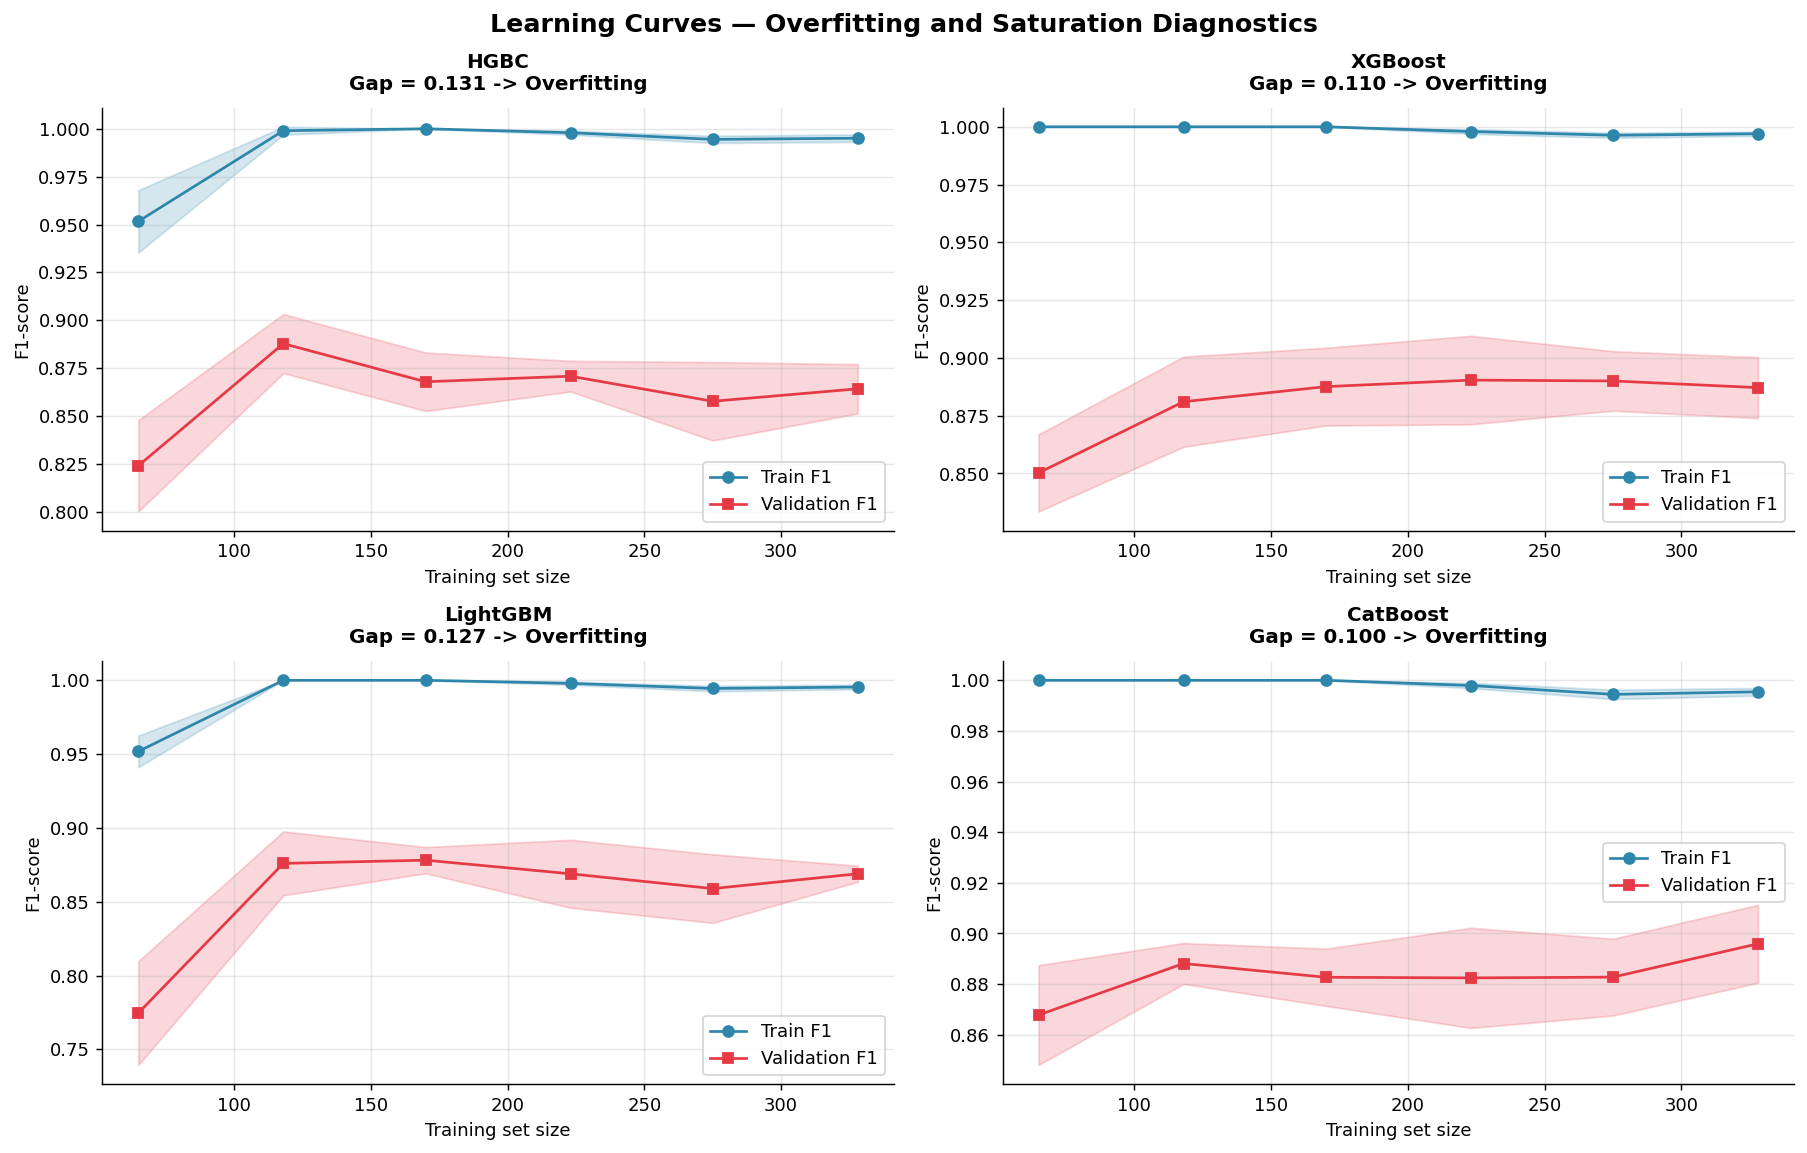

In [24]:
models_for_lc = ['HGBC', 'XGBoost', 'LightGBM', 'CatBoost']
train_sizes = np.linspace(0.2, 1.0, 6)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, name in zip(axes, models_for_lc):
    pipe = models[name]
    sizes_abs, train_sc, val_sc = learning_curve(
        pipe, X_arr, y_arr,
        train_sizes=train_sizes, cv=cv,
        scoring='f1', n_jobs=-1, random_state=RANDOM_STATE
    )
    tr_mean, tr_std = train_sc.mean(axis=1), train_sc.std(axis=1)
    va_mean, va_std = val_sc.mean(axis=1),   val_sc.std(axis=1)

    ax.plot(sizes_abs, tr_mean, 'o-', label='Train F1', color='#2E86AB')
    ax.fill_between(sizes_abs, tr_mean - tr_std, tr_mean + tr_std, alpha=0.2, color='#2E86AB')
    ax.plot(sizes_abs, va_mean, 's-', label='Validation F1', color='#E63946')
    ax.fill_between(sizes_abs, va_mean - va_std, va_mean + va_std, alpha=0.2, color='#E63946')

    gap = tr_mean[-1] - va_mean[-1]
    diagnosis = 'Overfitting' if gap > 0.05 else ('Possible underfitting' if va_mean[-1] < 0.7 else 'Well balanced')
    ax.set_title(f'{name}\nGap = {gap:.3f} -> {diagnosis}')
    ax.set_xlabel('Training set size')
    ax.set_ylabel('F1-score')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Learning Curves — Overfitting and Saturation Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.5 Decision Threshold Sweep and Error Analysis

By default the classifier uses a 0.5 threshold: if probability ≥ 0.5 → class 1. This is often poor in medicine because:

- **False Negatives** (FN: missing a sick patient) are usually more costly than **False Positives** (FP: unnecessary follow-up).
- The class may be imbalanced, so 0.5 produces biased predictions.

We sweep thresholds from 0.05 to 0.95 and pick the one that maximises F1 (compromise) and, separately, the one that delivers recall ≥ 0.85 (clinical choice).

In [25]:
best_model_name = cv_df.groupby('model')['f1'].mean().idxmax()
print(f'Best model by mean F1: {best_model_name}')

best_pipe = models[best_model_name]
proba_cv = cross_val_predict(best_pipe, X_arr, y_arr, cv=cv, method='predict_proba')[:, 1]

thresholds = np.linspace(0.05, 0.95, 91)
rows = []
for t in thresholds:
    pred = (proba_cv >= t).astype(int)
    if pred.sum() == 0 or pred.sum() == len(pred):
        continue
    rows.append({
        'threshold': t,
        'precision': precision_score(y_arr, pred, zero_division=0),
        'recall':    recall_score(y_arr, pred),
        'f1':        f1_score(y_arr, pred),
        'accuracy':  accuracy_score(y_arr, pred),
    })

th_df = pd.DataFrame(rows)

best_f1_t      = th_df.loc[th_df['f1'].idxmax(), 'threshold']
candidates_85  = th_df[th_df['recall'] >= 0.85]
best_recall_t  = candidates_85.loc[candidates_85['f1'].idxmax(), 'threshold'] if not candidates_85.empty else None

print(f'Threshold that maximises F1:    {best_f1_t:.2f}')
if best_recall_t is not None:
    print(f'Threshold for recall >= 0.85 + max F1: {best_recall_t:.2f}')

Best model by mean F1: CatBoost


Threshold that maximises F1:    0.12
Threshold for recall >= 0.85 + max F1: 0.12


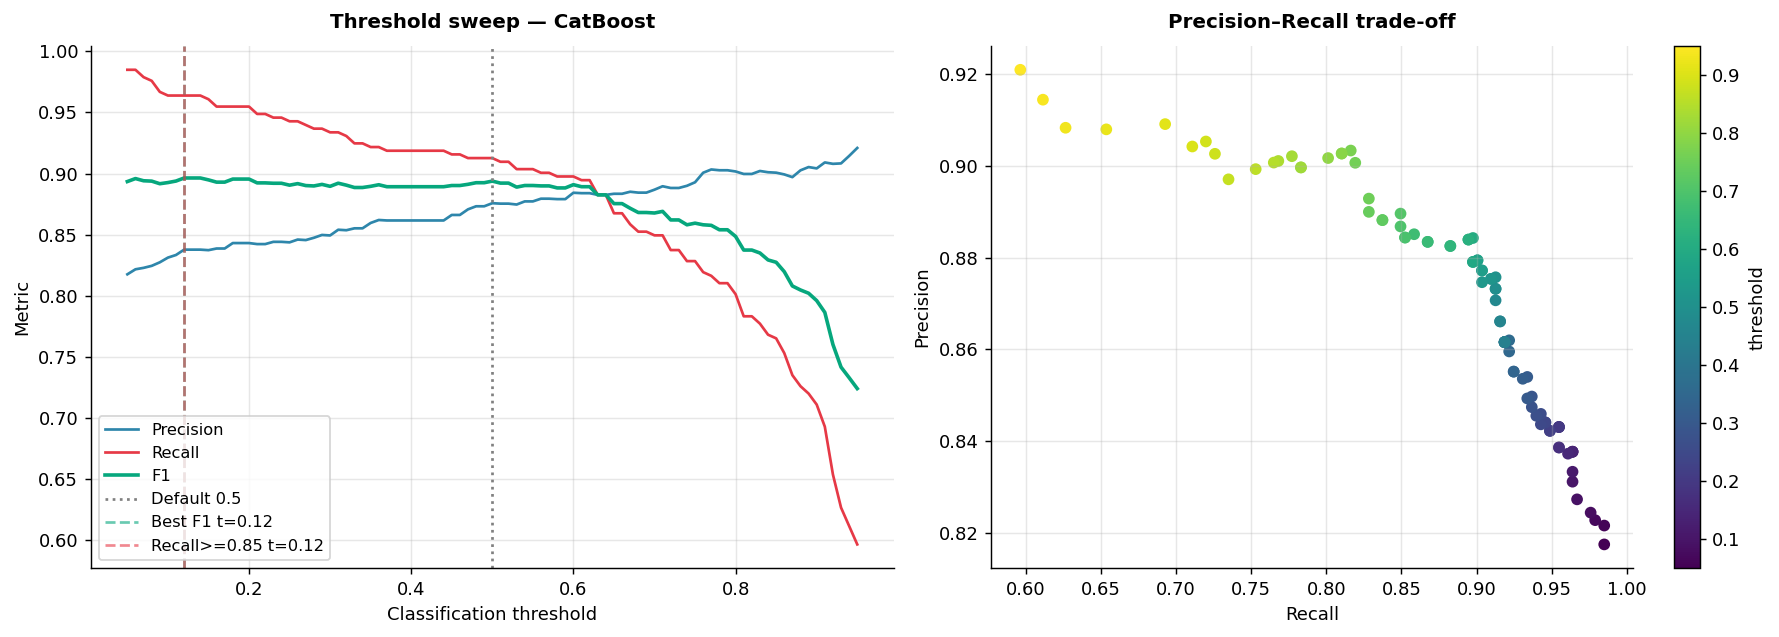

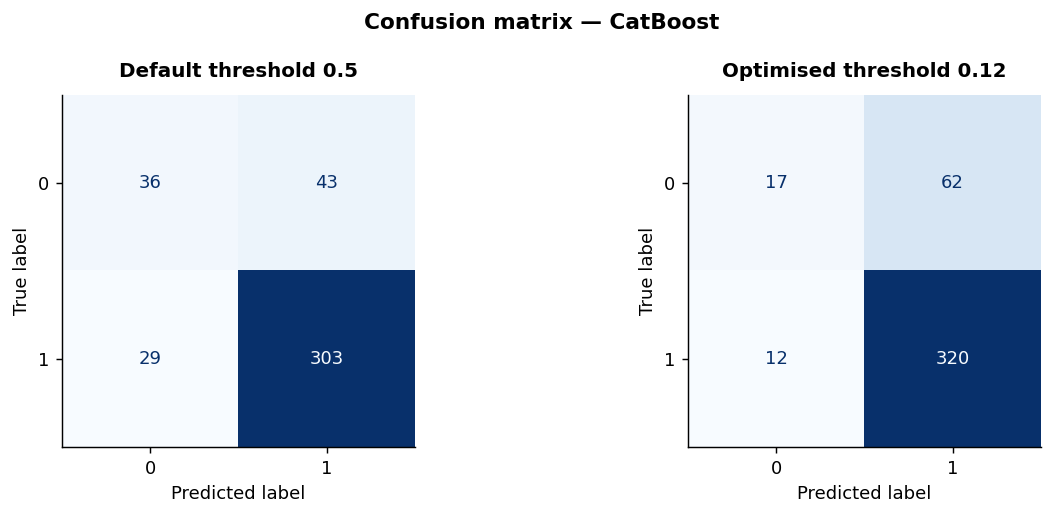

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(th_df['threshold'], th_df['precision'], label='Precision', color='#2E86AB')
ax.plot(th_df['threshold'], th_df['recall'],    label='Recall',    color='#E63946')
ax.plot(th_df['threshold'], th_df['f1'],        label='F1',        color='#06A77D', linewidth=2)
ax.axvline(0.5, color='gray', linestyle=':', label='Default 0.5')
ax.axvline(best_f1_t, color='#06A77D', linestyle='--', alpha=0.6, label=f'Best F1 t={best_f1_t:.2f}')
if best_recall_t is not None:
    ax.axvline(best_recall_t, color='#E63946', linestyle='--', alpha=0.6, label=f'Recall>=0.85 t={best_recall_t:.2f}')
ax.set_title(f'Threshold sweep — {best_model_name}')
ax.set_xlabel('Classification threshold')
ax.set_ylabel('Metric')
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)

ax2 = axes[1]
sc = ax2.scatter(th_df['recall'], th_df['precision'], c=th_df['threshold'], cmap='viridis', s=30)
plt.colorbar(sc, ax=ax2, label='threshold')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision–Recall trade-off')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, t, title in zip(axes, [0.5, best_f1_t],
                        ['Default threshold 0.5', f'Optimised threshold {best_f1_t:.2f}']):
    pred = (proba_cv >= t).astype(int)
    cm = confusion_matrix(y_arr, pred)
    ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
plt.suptitle(f'Confusion matrix — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.show()

### 5.6 Final Summary Table for Report

In [27]:
summary = (cv_df.groupby('model')
             .agg(F1=('f1', 'mean'),
                  F1_std=('f1', 'std'),
                  Recall=('recall', 'mean'),
                  AUC=('auc', 'mean'),
                  Train_sec=('train_time_sec', 'mean'),
                  Predict_sec=('predict_time_sec', 'mean'))
             .round(4))
best_method = {m: brier_df.loc[m, 'best'] for m in summary.index}
best_brier  = {m: min(calibration_results[m][k] for k in ['raw_brier','sigmoid_brier','isotonic_brier'])
               for m in summary.index}
summary['Best_calib']  = pd.Series(best_method)
summary['Brier_value'] = pd.Series(best_brier).round(4)
summary

,F1,F1_std,Recall,AUC,Train_sec,Predict_sec,Best_calib,Brier_value
model,,,,,,,,
CatBoost,0.8936,0.0154,0.9126,0.7738,0.4712,0.0017,sigmoid,0.1416
HGBC,0.8578,0.0140,0.8645,0.7429,0.1257,0.0025,sigmoid,0.1515
LightGBM,0.8784,0.0119,0.9038,0.7400,0.0619,0.0011,sigmoid,0.1485
NeuralNetwork_MLP,0.8901,0.0130,0.9758,0.7144,0.0132,0.0002,sigmoid,0.1556
XGBoost,0.8882,0.0095,0.9338,0.7444,0.1235,0.0014,sigmoid,0.1458


## Stage 6 - Extra Clinical Graphs and Final Diagnostics

This section was added to make the notebook visually stronger and closer to a high-scoring project example. It adds subgroup/bias plots, ROC and precision-recall curves, a confusion matrix heatmap, and deeper error analysis.

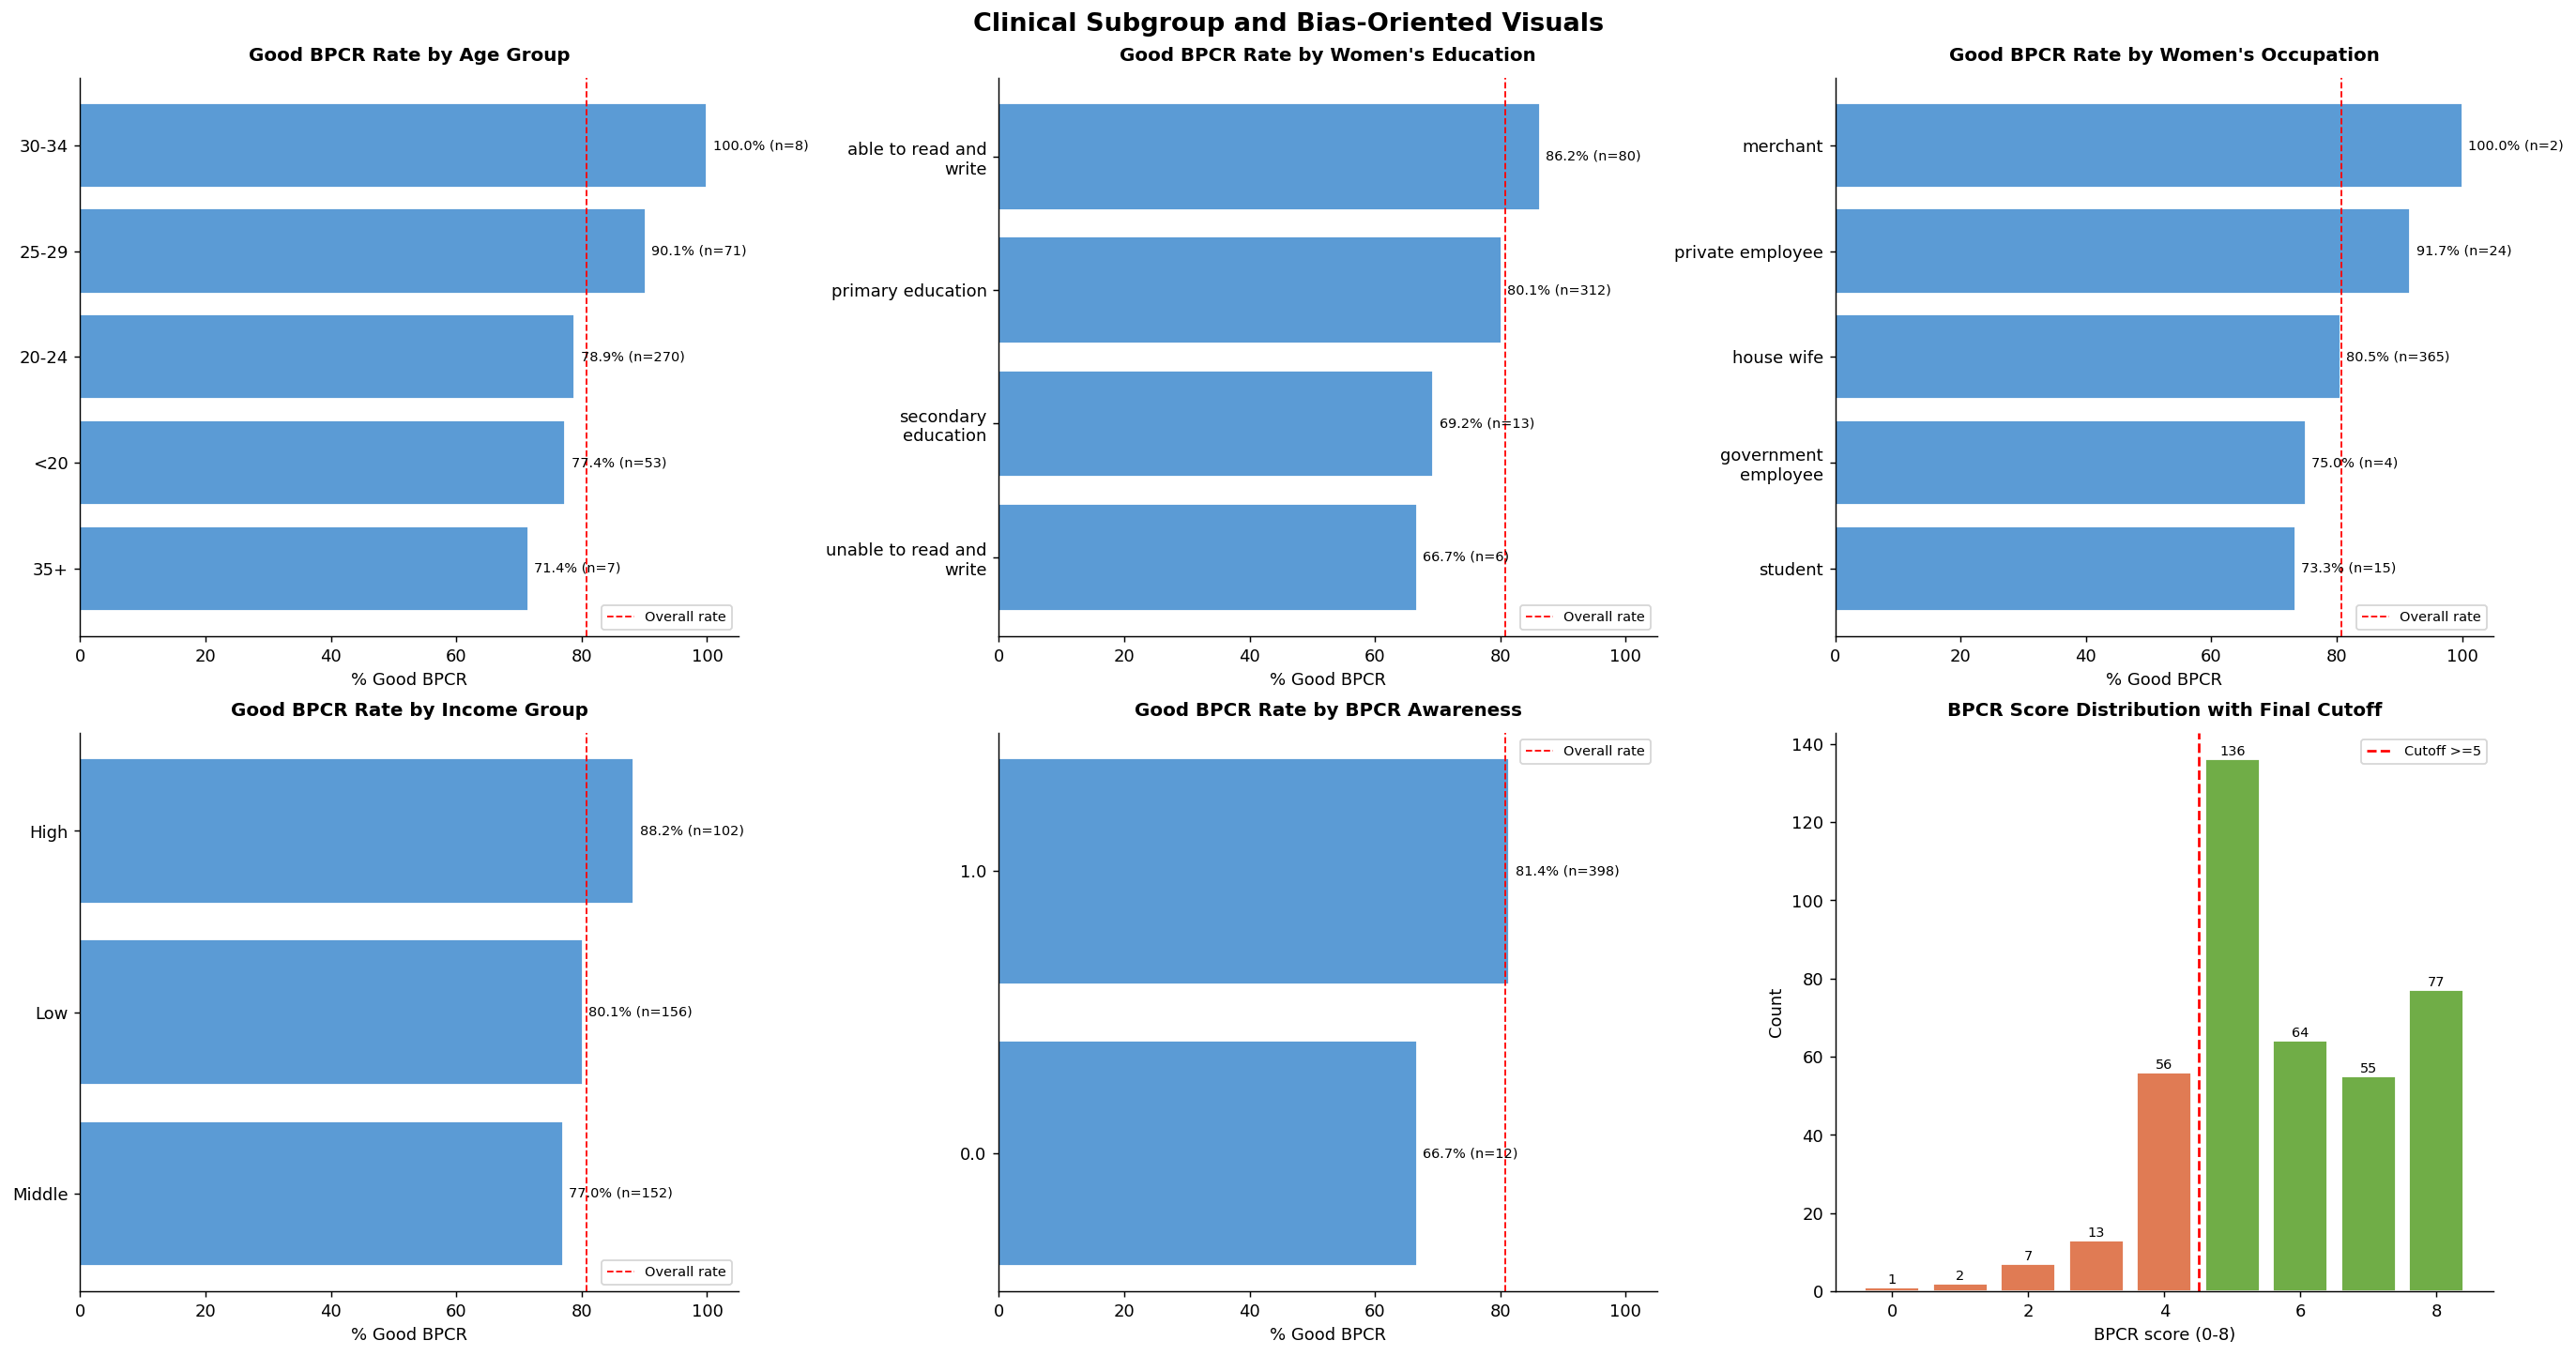

In [28]:
# Extra clinical/bias plots for the KAP-BPCR project
import textwrap

def wrap_label2(x, width=18):
    return '\n'.join(textwrap.wrap(str(x).replace('_', ' '), width=width, break_long_words=False))

# Use the second-part target if available; it is the unified final target.
plot_df = df.copy()
if 'good_bpcr_practice' not in plot_df.columns:
    plot_df['good_bpcr_practice'] = df['bpcr_adequate']
if 'bpcr_practice_score' not in plot_df.columns and 'bpcr_score' in plot_df.columns:
    plot_df['bpcr_practice_score'] = df['bpcr_score']

age_col = '@_1_1_Age' if '@_1_1_Age' in plot_df.columns else 'age'
income_col = '@_1_7_What_is_your_average_monthly_income' if '@_1_7_What_is_your_average_monthly_income' in plot_df.columns else 'income'
edu_col = '@_1_4_Educational_status_of_the_women' if '@_1_4_Educational_status_of_the_women' in plot_df.columns else 'edu_women'
occ_col = '@_1_3_Occupation_of_the_women' if '@_1_3_Occupation_of_the_women' in plot_df.columns else 'occ_women'
heard_col = '@_2_7_Have_you_ever_heard_the_t' if '@_2_7_Have_you_ever_heard_the_t' in plot_df.columns else 'heard_bpcr'

def rate_table(col, top_n=None):
    tmp = plot_df[[col, 'good_bpcr_practice']].dropna().copy()
    if top_n and tmp[col].nunique() > top_n:
        keep = tmp[col].value_counts().head(top_n).index
        tmp[col] = np.where(tmp[col].isin(keep), tmp[col], 'Other')
    out = tmp.groupby(col)['good_bpcr_practice'].agg(['mean', 'count']).reset_index()
    return out.sort_values('mean')

plot_df['age_group'] = pd.cut(plot_df[age_col], bins=[0, 19, 24, 29, 34, 100],
                              labels=['<20', '20-24', '25-29', '30-34', '35+'])
try:
    plot_df['income_group'] = pd.qcut(plot_df[income_col], q=3, labels=['Low', 'Middle', 'High'], duplicates='drop')
except Exception:
    plot_df['income_group'] = 'Unknown'

fig, axes = plt.subplots(2, 3, figsize=(21, 11), constrained_layout=True)
charts = [
    ('age_group', 'Good BPCR Rate by Age Group'),
    (edu_col, "Good BPCR Rate by Women's Education"),
    (occ_col, "Good BPCR Rate by Women's Occupation"),
    ('income_group', 'Good BPCR Rate by Income Group'),
    (heard_col, 'Good BPCR Rate by BPCR Awareness'),
]
for ax, (col, title) in zip(axes.ravel()[:5], charts):
    rt = rate_table(col, top_n=6)
    bars = ax.barh([wrap_label2(x, 18) for x in rt[col]], rt['mean'] * 100,
                   color='#5B9BD5', edgecolor='white')
    for bar, rate, n in zip(bars, rt['mean'], rt['count']):
        ax.text(rate*100 + 1, bar.get_y()+bar.get_height()/2,
                f'{rate*100:.1f}% (n={int(n)})', va='center', fontsize=8)
    ax.set_xlim(0, 105)
    ax.set_xlabel('% Good BPCR')
    ax.set_title(title)
    ax.axvline(plot_df['good_bpcr_practice'].mean()*100, color='red', linestyle='--', lw=1,
               label='Overall rate')
    ax.legend(fontsize=8)

score_counts = plot_df['bpcr_practice_score'].value_counts().sort_index()
colors = ['#E07B54' if x < 5 else '#70AD47' for x in score_counts.index]
axes.ravel()[5].bar(score_counts.index.astype(int), score_counts.values, color=colors, edgecolor='white')
axes.ravel()[5].axvline(4.5, color='red', linestyle='--', lw=1.5, label='Cutoff >=5')
for x, v in score_counts.items():
    axes.ravel()[5].text(int(x), v+1, str(int(v)), ha='center', fontsize=8)
axes.ravel()[5].set_title('BPCR Score Distribution with Final Cutoff')
axes.ravel()[5].set_xlabel('BPCR score (0-8)')
axes.ravel()[5].set_ylabel('Count')
axes.ravel()[5].legend(fontsize=8)

fig.suptitle('Clinical Subgroup and Bias-Oriented Visuals', fontsize=15, fontweight='bold')
plt.savefig('fig_kap_clinical_subgroup_bias.png', bbox_inches='tight', dpi=150)
plt.show()

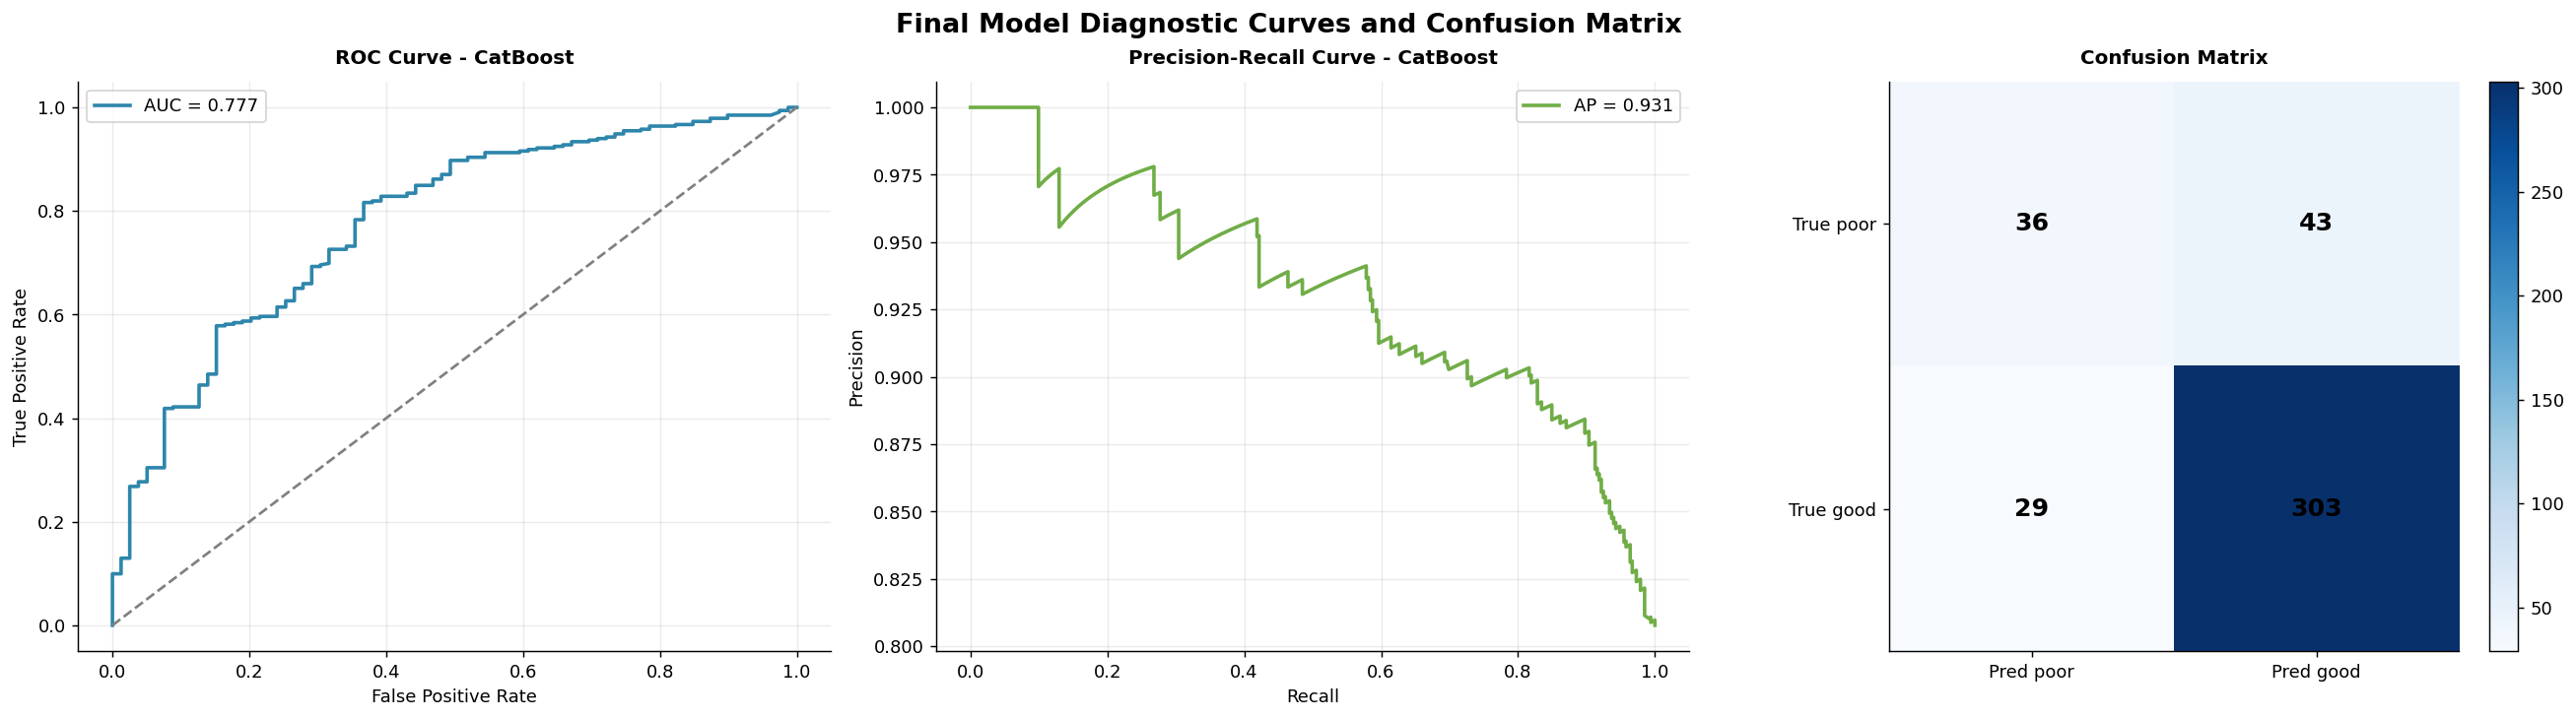

In [29]:
# ROC curve, Precision-Recall curve, and confusion matrix for the best model
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score, ConfusionMatrixDisplay

# Some earlier cells use cv_results as a list, so choose the valid results table safely.
if isinstance(cv_results, pd.DataFrame):
    results_for_diag = cv_results.copy()
elif 'cv_df' in globals() and isinstance(cv_df, pd.DataFrame):
    results_for_diag = cv_df.copy()
else:
    raise TypeError('No valid CV results DataFrame found for diagnostics')

best_model_name = results_for_diag.groupby('model')['f1'].mean().sort_values(ascending=False).index[0]
if 'cv_predictions' in globals() and isinstance(cv_predictions, pd.DataFrame) and best_model_name in cv_predictions['model'].unique():
    best_preds = cv_predictions[cv_predictions['model'] == best_model_name].copy()
else:
    # Rebuild fold predictions from the simpler model set if cv_predictions was overwritten or unavailable.
    best_preds_rows = []
    model_obj = models[best_model_name]
    for fold, (tr, te) in enumerate(cv.split(X_arr, y_arr)):
        model_obj.fit(X_arr[tr], y_arr[tr])
        prob = model_obj.predict_proba(X_arr[te])[:, 1]
        pred = (prob >= 0.5).astype(int)
        best_preds_rows.append(pd.DataFrame({
            'model': best_model_name, 'fold': fold, 'row_index': te,
            'y_true': y_arr[te], 'y_prob': prob, 'y_pred': pred
        }))
    best_preds = pd.concat(best_preds_rows, ignore_index=True)

fpr, tpr, _ = roc_curve(best_preds['y_true'], best_preds['y_prob'])
prec, rec, _ = precision_recall_curve(best_preds['y_true'], best_preds['y_prob'])
ap = average_precision_score(best_preds['y_true'], best_preds['y_prob'])
auc_value = roc_auc_score(best_preds['y_true'], best_preds['y_prob'])
cm = confusion_matrix(best_preds['y_true'], best_preds['y_pred'])

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), constrained_layout=True)
axes[0].plot(fpr, tpr, color='#2E86AB', lw=2, label=f'AUC = {auc_value:.3f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curve - {best_model_name}')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(rec, prec, color='#70AD47', lw=2, label=f'AP = {ap:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve - {best_model_name}')
axes[1].legend()
axes[1].grid(alpha=0.25)

im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_xticks([0, 1]); axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['Pred poor', 'Pred good'])
axes[2].set_yticklabels(['True poor', 'True good'])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14, fontweight='bold')
axes[2].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

fig.suptitle('Final Model Diagnostic Curves and Confusion Matrix', fontsize=15, fontweight='bold')
plt.savefig('fig_kap_roc_pr_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

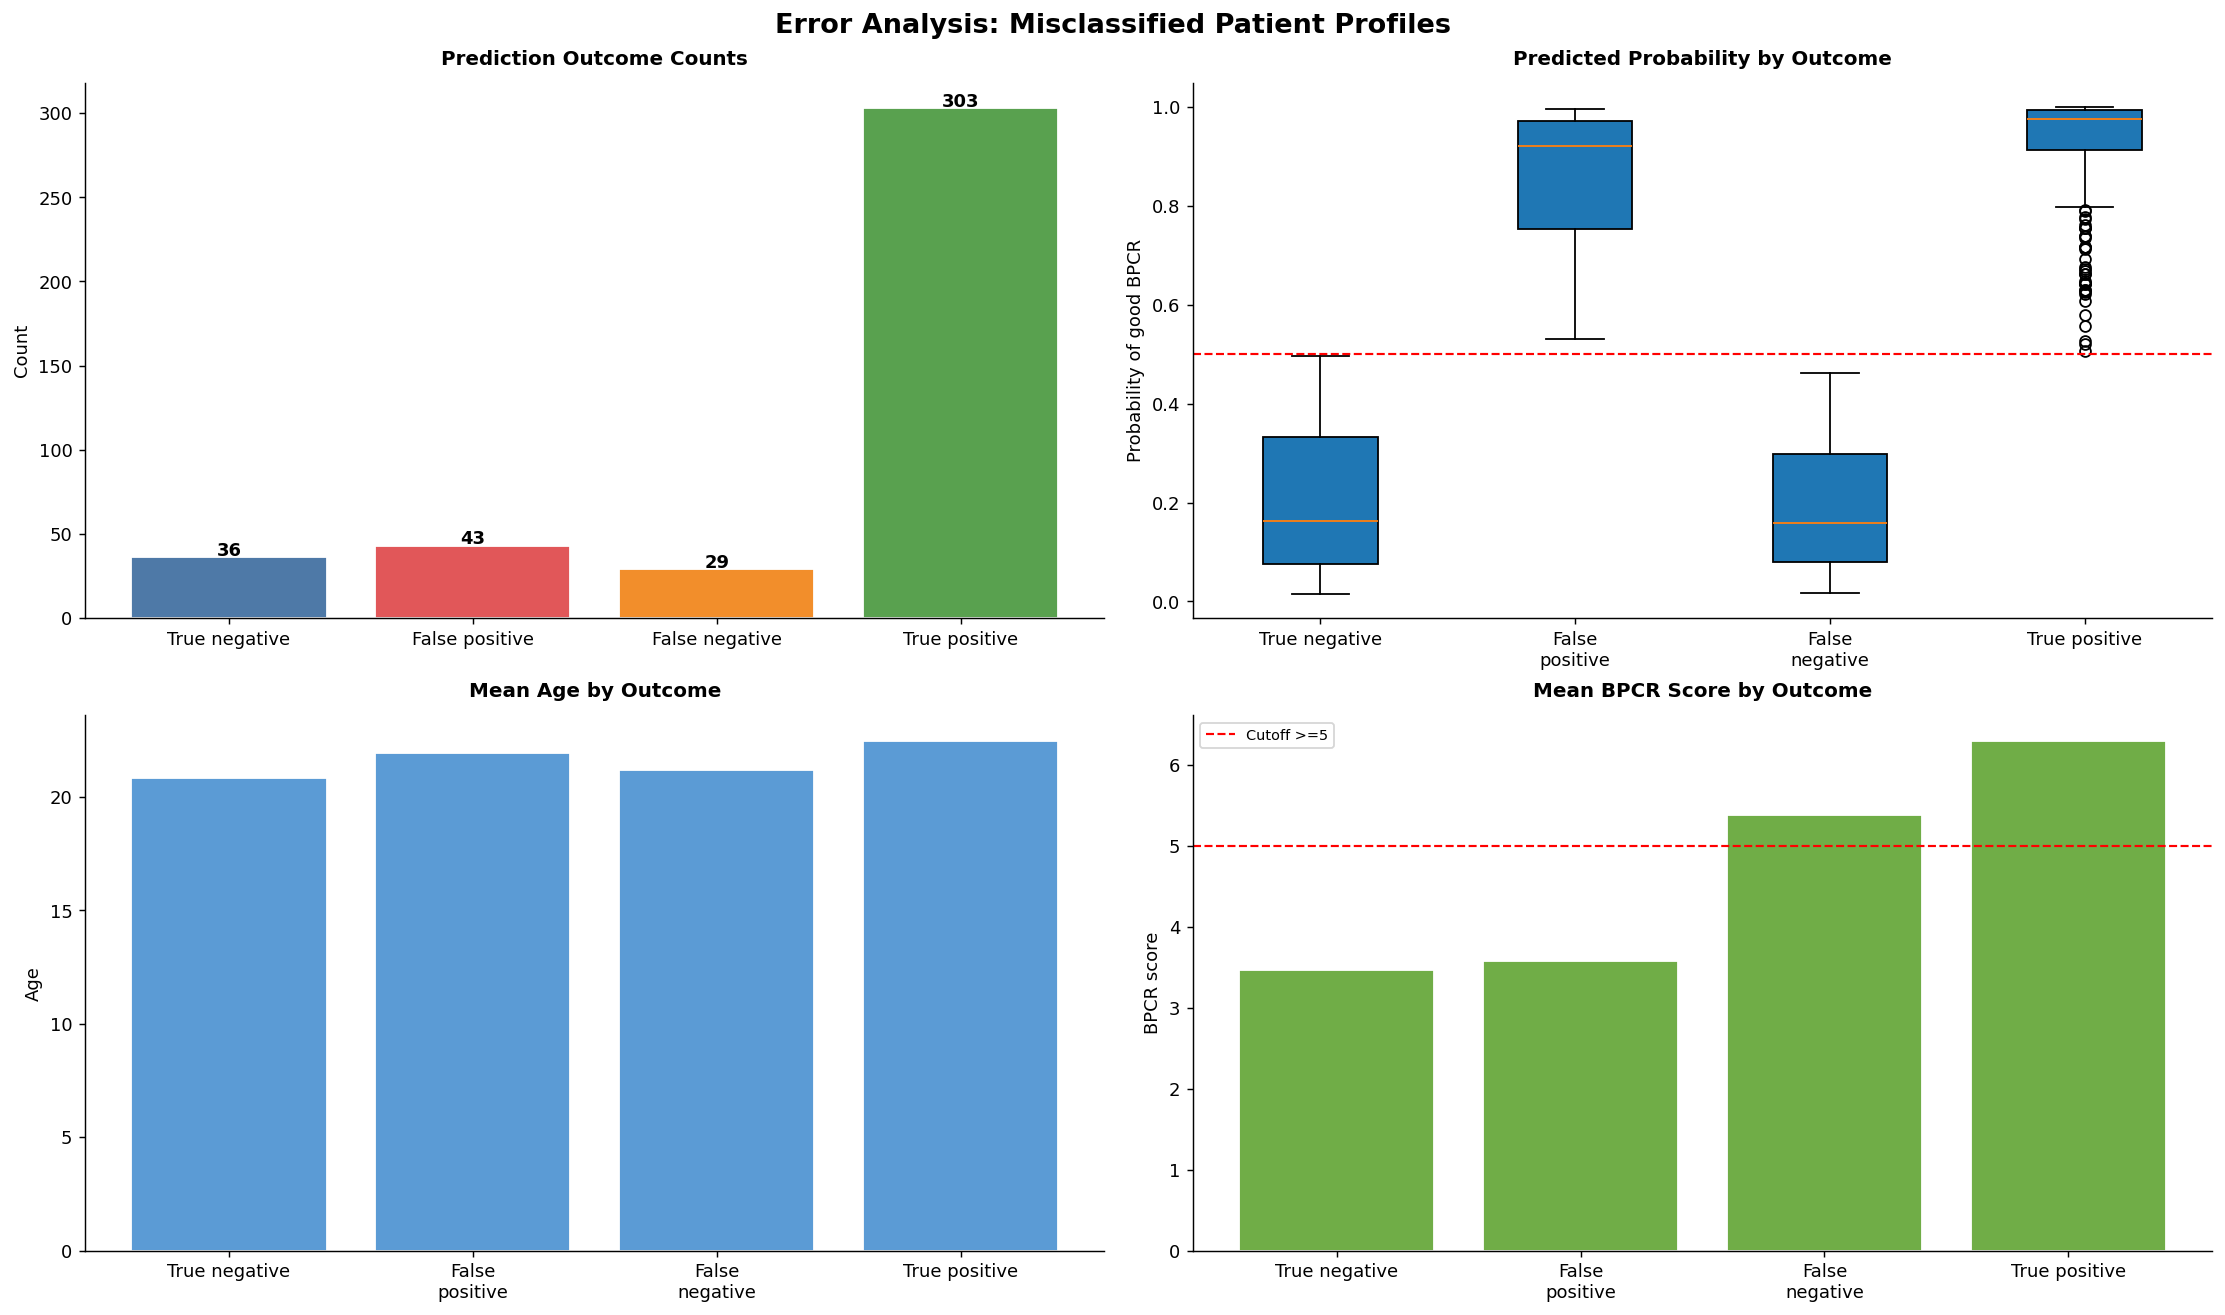

age                income               bpcr_practice_score  \
                 mean median count     mean  median count                mean   
outcome                                                                         
False negative  21.21   20.0    29  3044.83  2500.0    29                5.38   
False positive  21.93   21.0    43  3151.16  3000.0    43                3.58   
True negative   20.86   20.0    35  3182.86  3000.0    35                3.47   
True positive   22.48   22.0   302  3410.23  3000.0   303                6.30   

                            predicted_probability               
               median count                  mean median count  
outcome                                                         
False negative    5.0    29                  0.19   0.16    29  
False positive    4.0    43                  0.86   0.92    43  
True negative     4.0    36                  0.21   0.16    36  
True positive     6.0   303                  0.93   0.98   303

In [30]:
# Deeper error analysis: what kind of patients are misclassified?
err = best_preds.copy()
err['outcome'] = np.select(
    [
        (err['y_true'] == 1) & (err['y_pred'] == 1),
        (err['y_true'] == 0) & (err['y_pred'] == 0),
        (err['y_true'] == 0) & (err['y_pred'] == 1),
        (err['y_true'] == 1) & (err['y_pred'] == 0),
    ],
    ['True positive', 'True negative', 'False positive', 'False negative'],
    default='Other'
)

profile = plot_df.iloc[err['row_index'].astype(int).values][[age_col, income_col, 'bpcr_practice_score', 'good_bpcr_practice']].copy()
profile['outcome'] = err['outcome'].values
profile['predicted_probability'] = err['y_prob'].values

fig, axes = plt.subplots(2, 2, figsize=(17, 10), constrained_layout=True)
order = ['True negative', 'False positive', 'False negative', 'True positive']
order = [o for o in order if o in profile['outcome'].unique()]

counts = profile['outcome'].value_counts().reindex(order)
axes[0,0].bar([wrap_label2(x, 14) for x in counts.index], counts.values,
              color=['#4E79A7', '#E15759', '#F28E2B', '#59A14F'][:len(counts)], edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v+1, str(int(v)), ha='center', fontweight='bold')
axes[0,0].set_title('Prediction Outcome Counts')
axes[0,0].set_ylabel('Count')

box_data = [profile.loc[profile['outcome']==o, 'predicted_probability'] for o in order]
axes[0,1].boxplot(box_data, labels=[wrap_label2(x, 13) for x in order], patch_artist=True)
axes[0,1].axhline(0.5, color='red', linestyle='--', lw=1.2)
axes[0,1].set_title('Predicted Probability by Outcome')
axes[0,1].set_ylabel('Probability of good BPCR')

age_summary = profile.groupby('outcome')[age_col].mean().reindex(order)
axes[1,0].bar([wrap_label2(x, 13) for x in age_summary.index], age_summary.values,
              color='#5B9BD5', edgecolor='white')
axes[1,0].set_title('Mean Age by Outcome')
axes[1,0].set_ylabel('Age')

score_summary = profile.groupby('outcome')['bpcr_practice_score'].mean().reindex(order)
axes[1,1].bar([wrap_label2(x, 13) for x in score_summary.index], score_summary.values,
              color='#70AD47', edgecolor='white')
axes[1,1].axhline(5, color='red', linestyle='--', lw=1.2, label='Cutoff >=5')
axes[1,1].set_title('Mean BPCR Score by Outcome')
axes[1,1].set_ylabel('BPCR score')
axes[1,1].legend(fontsize=8)

fig.suptitle('Error Analysis: Misclassified Patient Profiles', fontsize=15, fontweight='bold')
plt.savefig('fig_kap_error_profile_deep.png', bbox_inches='tight', dpi=150)
plt.show()

display(profile.groupby('outcome')[[age_col, income_col, 'bpcr_practice_score', 'predicted_probability']].agg(['mean', 'median', 'count']).round(2))